## Import required libraries

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score, accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import precision_recall_curve, roc_auc_score, f1_score
from sklearn.metrics import RocCurveDisplay
from imblearn.over_sampling import SMOTE, ADASYN
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [ ]:
train_data_path = '/content/drive/MyDrive/fraudTrain.csv'
test_data_path = '/content/drive/MyDrive/fraudTest.csv'

In [ ]:
# train_data_path = './fraudTrain.csv'
# test_data_path = './fraudTest.csv'

In [6]:
df_train = pd.read_csv(train_data_path)
df_test = pd.read_csv(test_data_path)

In [7]:
df_train.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


In [8]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 23 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Unnamed: 0             1296675 non-null  int64  
 1   trans_date_trans_time  1296675 non-null  object 
 2   cc_num                 1296675 non-null  int64  
 3   merchant               1296675 non-null  object 
 4   category               1296675 non-null  object 
 5   amt                    1296675 non-null  float64
 6   first                  1296675 non-null  object 
 7   last                   1296675 non-null  object 
 8   gender                 1296675 non-null  object 
 9   street                 1296675 non-null  object 
 10  city                   1296675 non-null  object 
 11  state                  1296675 non-null  object 
 12  zip                    1296675 non-null  int64  
 13  lat                    1296675 non-null  float64
 14  long              

In [9]:
df_train.describe(include='all')

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
count,1.296675e+06,1296675,1.296675e+06,1296675,1296675,1.296675e+06,1296675,1296675,1296675,1296675,...,1.296675e+06,1.296675e+06,1.296675e+06,1296675,1296675,1296675,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06
unique,NaN,1274791,NaN,693,14,NaN,352,481,2,983,...,NaN,NaN,NaN,494,968,1296675,NaN,NaN,NaN,NaN
top,NaN,2019-04-22 16:02:01,NaN,fraud_Kilback LLC,gas_transport,NaN,Christopher,Smith,F,0069 Robin Brooks Apt. 695,...,NaN,NaN,NaN,Film/video editor,1977-03-23,0b242abb623afc578575680df30655b9,NaN,NaN,NaN,NaN
freq,NaN,4,NaN,4403,131659,NaN,26669,28794,709863,3123,...,NaN,NaN,NaN,9779,5636,1,NaN,NaN,NaN,NaN
mean,6.483370e+05,NaN,4.171920e+17,NaN,NaN,7.035104e+01,NaN,NaN,NaN,NaN,...,3.853762e+01,-9.022634e+01,8.882444e+04,NaN,NaN,NaN,1.349244e+09,3.853734e+01,-9.022646e+01,5.788652e-03
std,3.743180e+05,NaN,1.308806e+18,NaN,NaN,1.603160e+02,NaN,NaN,NaN,NaN,...,5.075808e+00,1.375908e+01,3.019564e+05,NaN,NaN,NaN,1.284128e+07,5.109788e+00,1.377109e+01,7.586269e-02
min,0.000000e+00,NaN,6.041621e+10,NaN,NaN,1.000000e+00,NaN,NaN,NaN,NaN,...,2.002710e+01,-1.656723e+02,2.300000e+01,NaN,NaN,NaN,1.325376e+09,1.902779e+01,-1.666712e+02,0.000000e+00
25%,3.241685e+05,NaN,1.800429e+14,NaN,NaN,9.650000e+00,NaN,NaN,NaN,NaN,...,3.462050e+01,-9.679800e+01,7.430000e+02,NaN,NaN,NaN,1.338751e+09,3.473357e+01,-9.689728e+01,0.000000e+00
50%,6.483370e+05,NaN,3.521417e+15,NaN,NaN,4.752000e+01,NaN,NaN,NaN,NaN,...,3.935430e+01,-8.747690e+01,2.456000e+03,NaN,NaN,NaN,1.349250e+09,3.936568e+01,-8.743839e+01,0.000000e+00
75%,9.725055e+05,NaN,4.642255e+15,NaN,NaN,8.314000e+01,NaN,NaN,NaN,NaN,...,4.194040e+01,-8.015800e+01,2.032800e+04,NaN,NaN,NaN,1.359385e+09,4.195716e+01,-8.023680e+01,0.000000e+00


In [10]:
df_train.shape

(1296675, 23)

In [11]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 555719 entries, 0 to 555718
Data columns (total 23 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Unnamed: 0             555719 non-null  int64  
 1   trans_date_trans_time  555719 non-null  object 
 2   cc_num                 555719 non-null  int64  
 3   merchant               555719 non-null  object 
 4   category               555719 non-null  object 
 5   amt                    555719 non-null  float64
 6   first                  555719 non-null  object 
 7   last                   555719 non-null  object 
 8   gender                 555719 non-null  object 
 9   street                 555719 non-null  object 
 10  city                   555719 non-null  object 
 11  state                  555719 non-null  object 
 12  zip                    555719 non-null  int64  
 13  lat                    555719 non-null  float64
 14  long                   555719 non-nu

In [12]:
df_test.describe(include='all')

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
count,555719.000000,555719,5.557190e+05,555719,555719,555719.000000,555719,555719,555719,555719,...,555719.000000,555719.000000,5.557190e+05,555719,555719,555719,5.557190e+05,555719.000000,555719.000000,555719.000000
unique,NaN,544760,NaN,693,14,NaN,341,471,2,924,...,NaN,NaN,NaN,478,910,555719,NaN,NaN,NaN,NaN
top,NaN,2020-12-19 16:02:22,NaN,fraud_Kilback LLC,gas_transport,NaN,Christopher,Smith,F,444 Robert Mews,...,NaN,NaN,NaN,Film/video editor,1977-03-23,2da90c7d74bd46a0caf3777415b3ebd3,NaN,NaN,NaN,NaN
freq,NaN,4,NaN,1859,56370,NaN,11443,12146,304886,1474,...,NaN,NaN,NaN,4119,2408,1,NaN,NaN,NaN,NaN
mean,277859.000000,NaN,4.178387e+17,NaN,NaN,69.392810,NaN,NaN,NaN,NaN,...,38.543253,-90.231325,8.822189e+04,NaN,NaN,NaN,1.380679e+09,38.542798,-90.231380,0.003860
std,160422.401459,NaN,1.309837e+18,NaN,NaN,156.745941,NaN,NaN,NaN,NaN,...,5.061336,13.721780,3.003909e+05,NaN,NaN,NaN,5.201104e+06,5.095829,13.733071,0.062008
min,0.000000,NaN,6.041621e+10,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,...,20.027100,-165.672300,2.300000e+01,NaN,NaN,NaN,1.371817e+09,19.027422,-166.671575,0.000000
25%,138929.500000,NaN,1.800429e+14,NaN,NaN,9.630000,NaN,NaN,NaN,NaN,...,34.668900,-96.798000,7.410000e+02,NaN,NaN,NaN,1.376029e+09,34.755302,-96.905129,0.000000
50%,277859.000000,NaN,3.521417e+15,NaN,NaN,47.290000,NaN,NaN,NaN,NaN,...,39.371600,-87.476900,2.408000e+03,NaN,NaN,NaN,1.380762e+09,39.376593,-87.445204,0.000000
75%,416788.500000,NaN,4.635331e+15,NaN,NaN,83.010000,NaN,NaN,NaN,NaN,...,41.894800,-80.175200,1.968500e+04,NaN,NaN,NaN,1.385867e+09,41.954163,-80.264637,0.000000


In [13]:
df_test.shape

(555719, 23)

## Combine the datasets

In [14]:
df_fraud = pd.concat([df_train, df_test])

In [15]:
df_fraud.shape

(1852394, 23)

## Drop duplicates from the data

In [16]:
df_fraud.drop_duplicates()
df_fraud.shape

(1852394, 23)

## Check for null values

In [17]:
100*df_fraud.isnull().mean()

Unnamed: 0               0.0
trans_date_trans_time    0.0
cc_num                   0.0
merchant                 0.0
category                 0.0
amt                      0.0
first                    0.0
last                     0.0
gender                   0.0
street                   0.0
city                     0.0
state                    0.0
zip                      0.0
lat                      0.0
long                     0.0
city_pop                 0.0
job                      0.0
dob                      0.0
trans_num                0.0
unix_time                0.0
merch_lat                0.0
merch_long               0.0
is_fraud                 0.0
dtype: float64

There are no columns with null/missing values

In [18]:
df_fraud.columns

Index(['Unnamed: 0', 'trans_date_trans_time', 'cc_num', 'merchant', 'category',
       'amt', 'first', 'last', 'gender', 'street', 'city', 'state', 'zip',
       'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time',
       'merch_lat', 'merch_long', 'is_fraud'],
      dtype='object')

## Convert the datetype of date-time columns

In [19]:
df_fraud['trans_date_trans_time'] = pd.to_datetime(df_fraud['trans_date_trans_time'], format='%Y-%m-%d %H:%M:%S')
df_fraud['dob'] = pd.to_datetime(df_fraud['dob'], format='%Y-%m-%d')

## Create new date and time columns

In [20]:
df_fraud['trans_date'] = df_fraud['trans_date_trans_time'].dt.date
df_fraud['trans_time'] = df_fraud['trans_date_trans_time'].dt.time

In [21]:
df_fraud.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,trans_date,trans_time
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0,2019-01-01,00:00:18
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0,2019-01-01,00:00:44
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0,2019-01-01,00:00:51
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0,2019-01-01,00:01:16
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0,2019-01-01,00:03:06


In [22]:
cc_grouped = df_fraud.groupby('cc_num')
grouped_df = pd.DataFrame(cc_grouped['is_fraud'].nunique())
grouped_df.rename(columns={'is_fraud':'fraud_flags'},inplace=True)
grouped_df.shape


(999, 1)

There are 999 unique credit cards in the dataset

In [23]:
100*grouped_df['fraud_flags'].value_counts(normalize=True)

fraud_flags
2    88.588589
1    11.411411
Name: proportion, dtype: float64

This tells that around 88% of the credit card customers have been victim of frauds atleast once

In [24]:
100*df_fraud['is_fraud'].value_counts(normalize=True)

is_fraud
0    99.478999
1     0.521001
Name: proportion, dtype: float64

99.4% of the transactions are not fraudulent. This implies the dataset is highly imbalanced

In [25]:
df_fraud['is_fraud'].value_counts()

is_fraud
0    1842743
1       9651
Name: count, dtype: int64

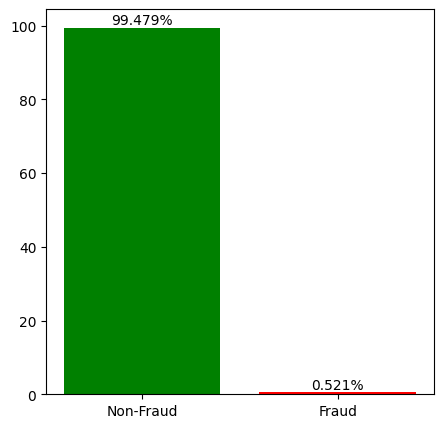

In [26]:
fig = plt.figure(figsize=(5,5))
ax = plt.bar(['Non-Fraud','Fraud'], df_fraud['is_fraud'].value_counts(normalize=True)*100,color=['g','r'])
plt.bar_label(ax, fmt='{:,.3f}%')
plt.show()


In [27]:
print(f"Total fraudulent transactions: {df_fraud[df_fraud['is_fraud']==1].shape[0]}")
print(f"Total amount defrauded: ${df_fraud[df_fraud['is_fraud']==1]['amt'].sum(): 0.2f}")
print(f"Average defrauded amt per transcation: $ {df_fraud[df_fraud['is_fraud']==1]['amt'].mean():0.2f}")

Total fraudulent transactions: 9651
Total amount defrauded: $ 5121413.29
Average defrauded amt per transcation: $ 530.66


## Univariate analysis

### States with fraudulent transactions

In [28]:
fraud_states = df_fraud[df_fraud['is_fraud']==1]['state'].value_counts()
fraud_states.index

Index(['NY', 'TX', 'PA', 'CA', 'OH', 'FL', 'IL', 'MI', 'MN', 'AL', 'VA', 'MO',
       'SC', 'WI', 'KY', 'IN', 'NE', 'IA', 'GA', 'MD', 'OK', 'OR', 'NC', 'AR',
       'KS', 'MS', 'NJ', 'TN', 'WV', 'ME', 'WA', 'NM', 'WY', 'CO', 'LA', 'SD',
       'MA', 'ND', 'NH', 'VT', 'MT', 'AZ', 'UT', 'CT', 'AK', 'NV', 'ID', 'DC',
       'HI', 'RI', 'DE'],
      dtype='object', name='state')

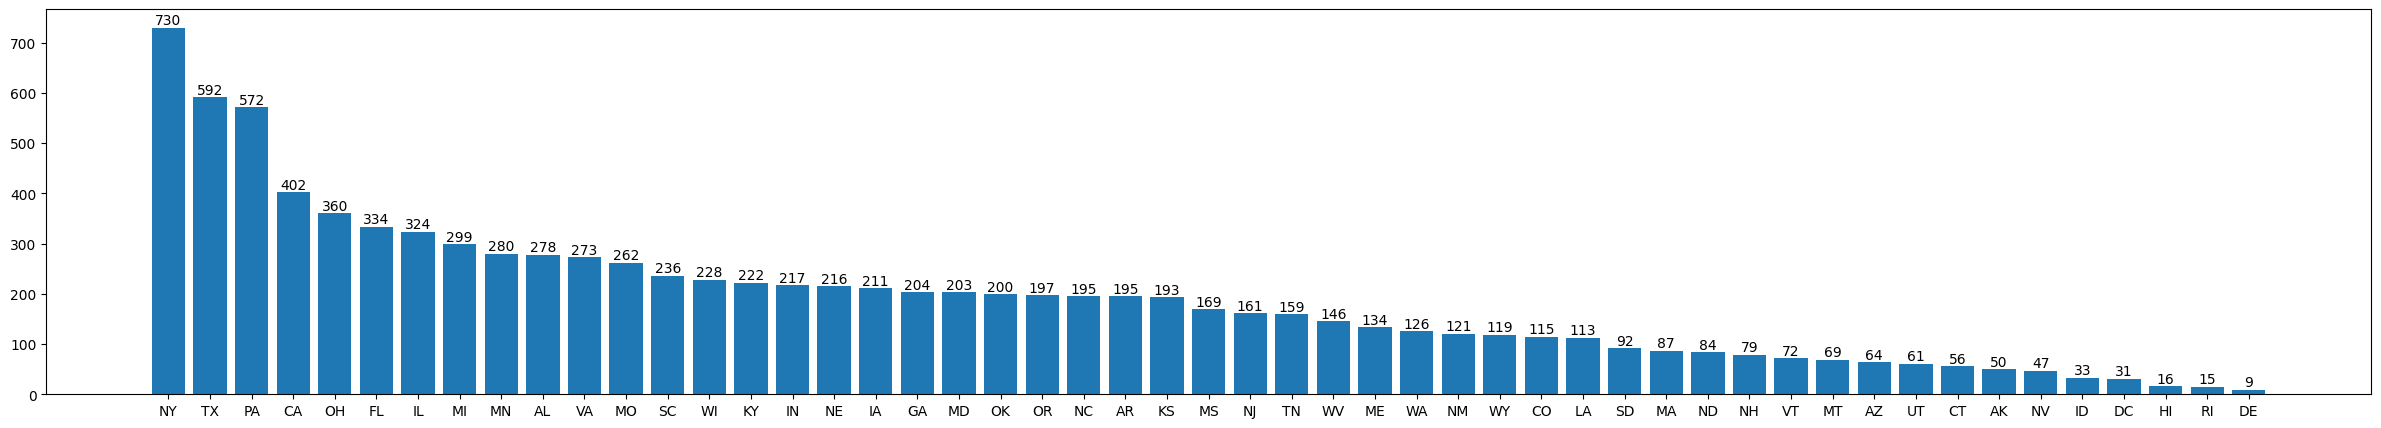

In [29]:
fig = plt.figure(figsize=(30,5))
ax=plt.bar(fraud_states.index, fraud_states)
plt.bar_label(ax,fmt='{:,.0f}')
plt.show()


NewYork seems to have recorded highest number of fraudulent transactions

### Transcation categories with frauds

In [30]:
fraud_cat = df_fraud[df_fraud['is_fraud']==1]['category'].value_counts()
fraud_cat.index

Index(['grocery_pos', 'shopping_net', 'misc_net', 'shopping_pos',
       'gas_transport', 'misc_pos', 'kids_pets', 'entertainment',
       'personal_care', 'home', 'food_dining', 'health_fitness', 'grocery_net',
       'travel'],
      dtype='object', name='category')

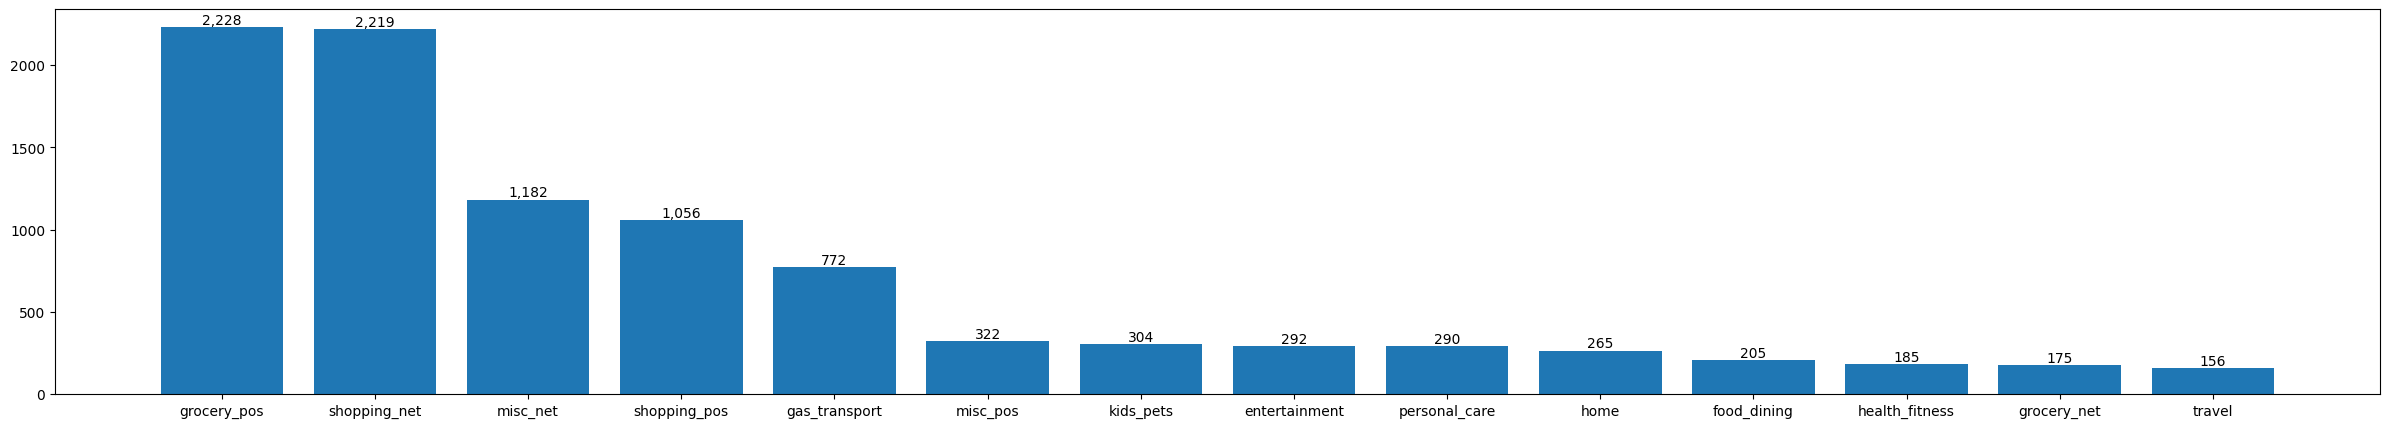

In [31]:
fig = plt.figure(figsize=(30,5))
ax=plt.bar(fraud_cat.index, fraud_cat)
plt.bar_label(ax,fmt='{:,.0f}')
plt.show()

Most of the frauds seem to happen at grocery point of sales or internet shopping

### Other categorical columns with fraudulent transactions

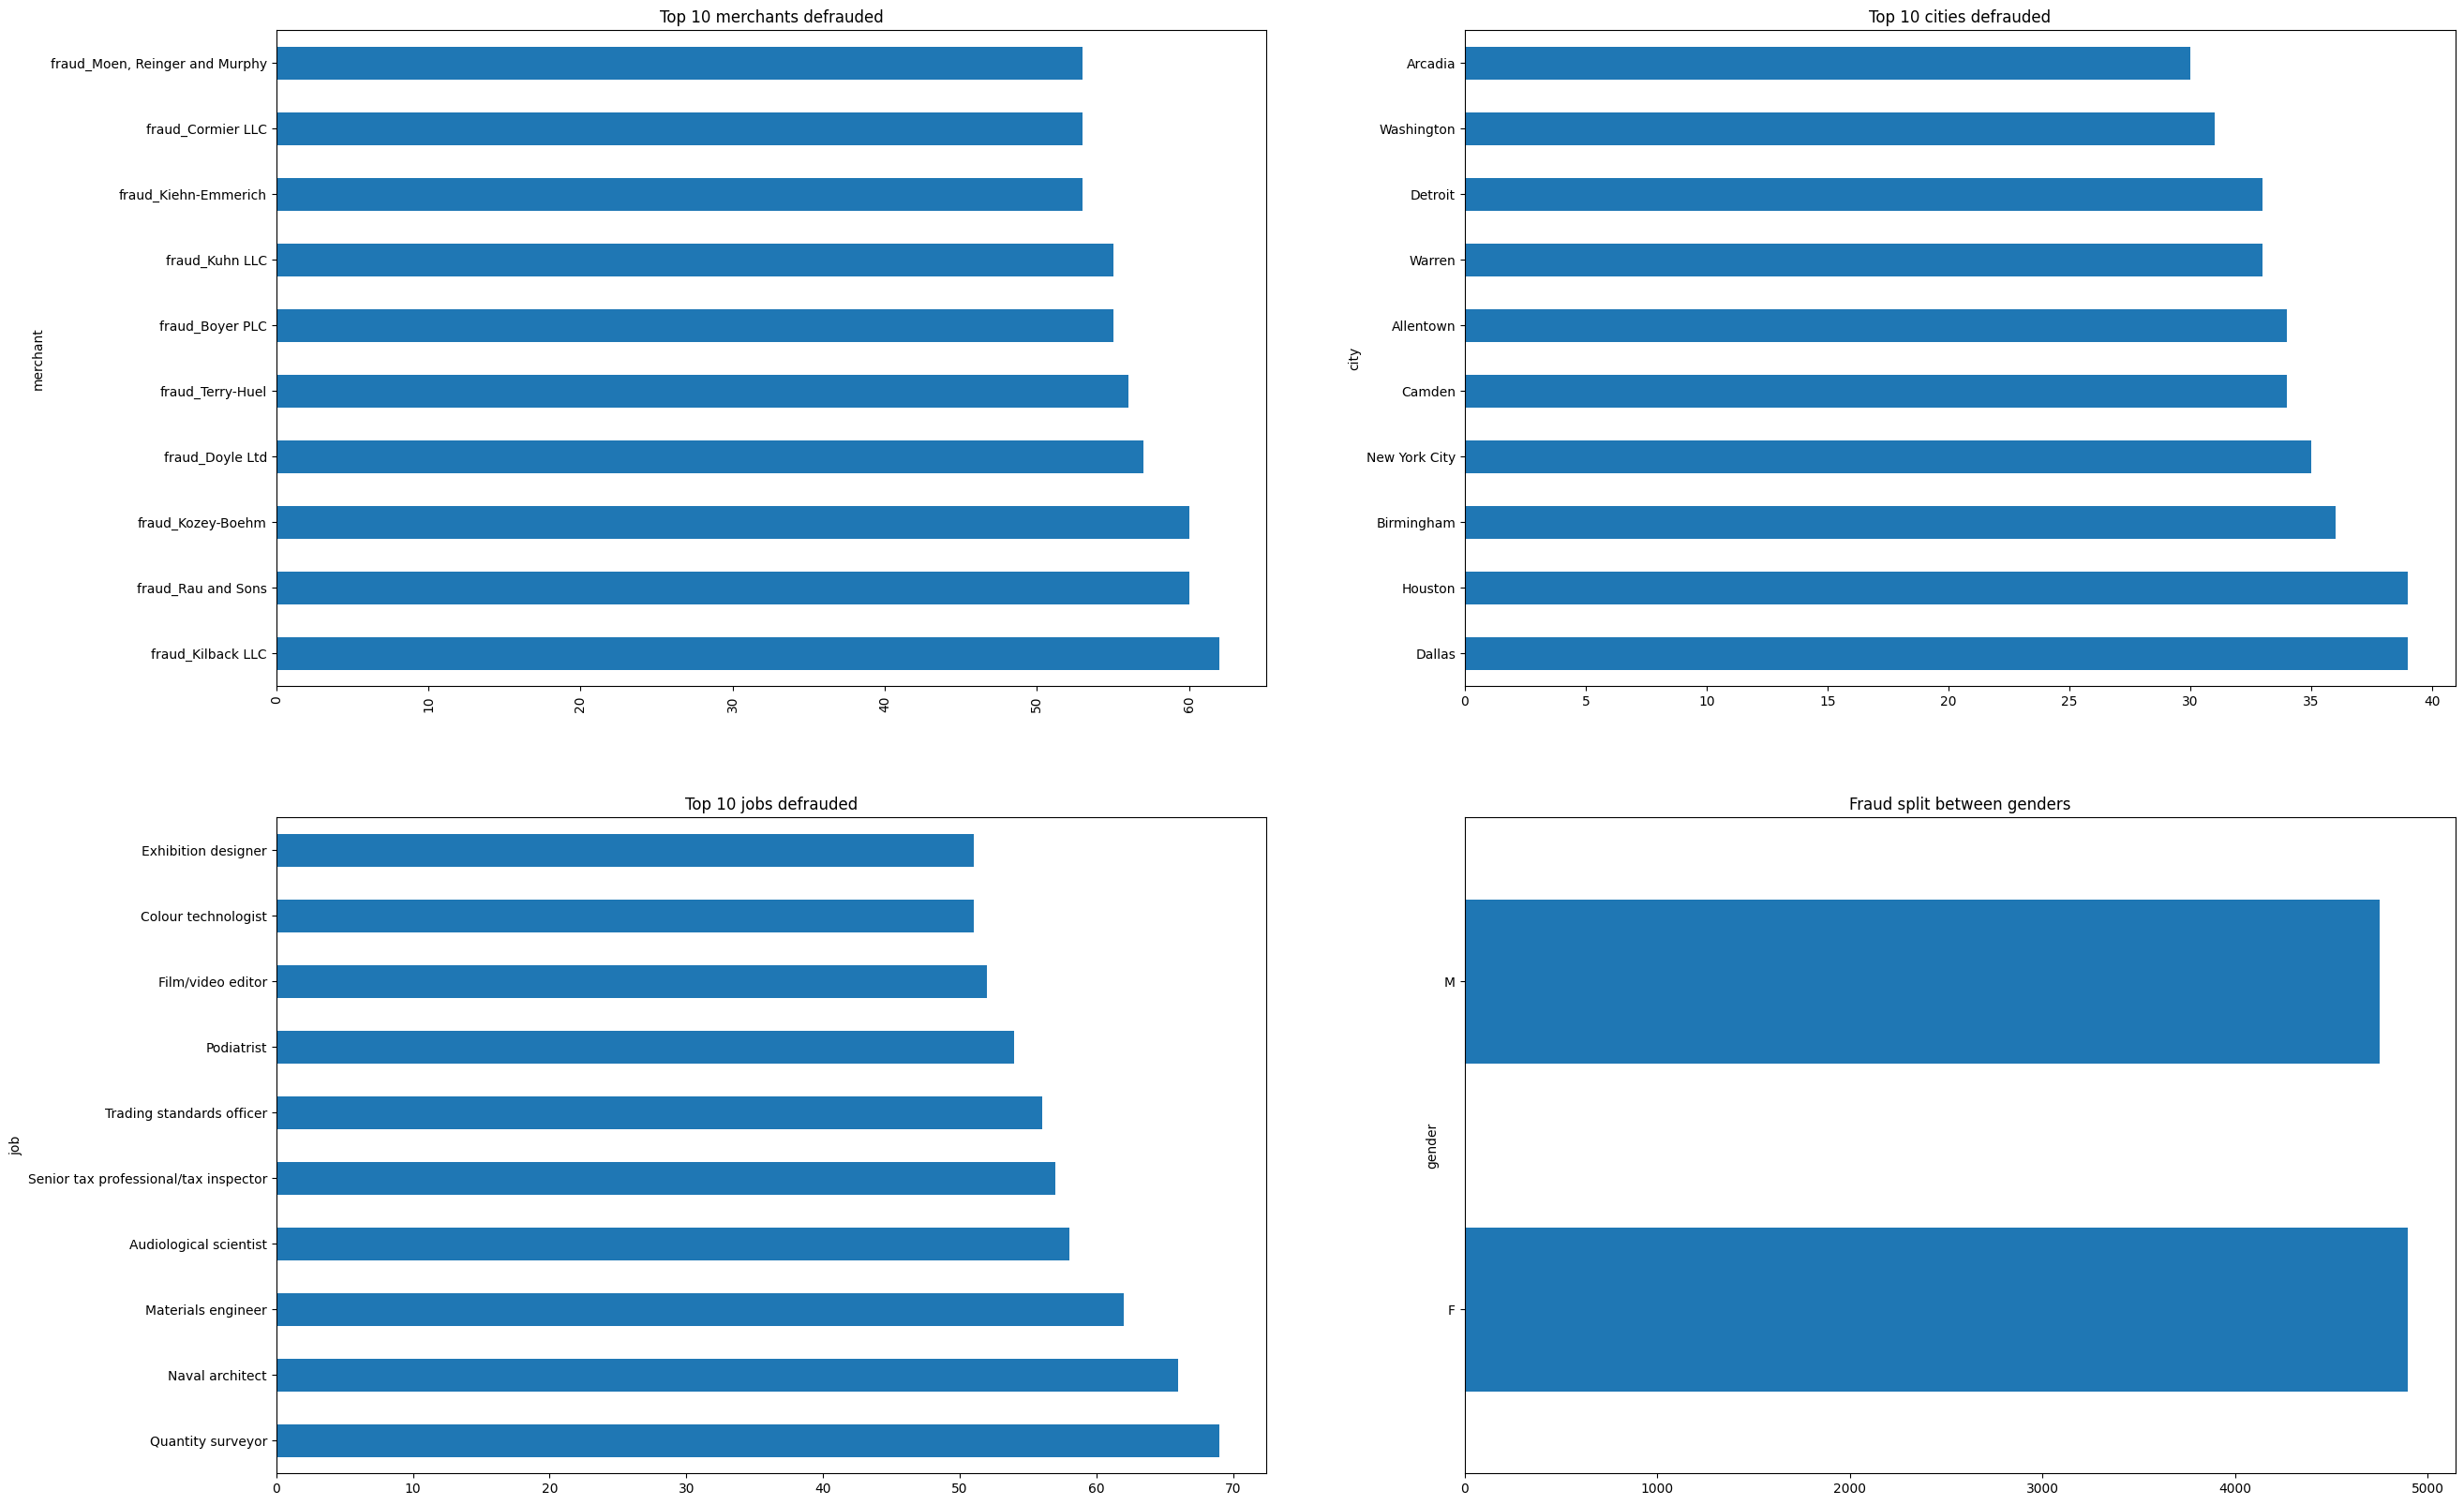

In [32]:
fig = plt.figure(figsize=(30,20))
plt.subplot(2,2,1)
df_fraud[df_fraud['is_fraud']==1]['merchant'].value_counts().head(10).plot.barh()
plt.title('Top 10 merchants defrauded')
plt.xticks(rotation=90)
plt.subplot(2,2,2)
df_fraud[df_fraud['is_fraud']==1]['city'].value_counts().head(10).plot.barh()
plt.title('Top 10 cities defrauded')
plt.subplot(2,2,3)
df_fraud[df_fraud['is_fraud']==1]['job'].value_counts().head(10).plot.barh()
plt.title('Top 10 jobs defrauded')
plt.subplot(2,2,4)
df_fraud[df_fraud['is_fraud']==1]['gender'].value_counts().plot.barh()
plt.title('Fraud split between genders')
plt.show()


- Merchant named Kilback LLC has the highest number of fraudulent transcations recorded
- Dallas and Houston cities seem to have more fraudulent transactions
- Quantity surveryor and Naval Architect jobs seem to be biggest victims of the fraud
- Though close, female customers seem to fall victim to fraud more

### Population vs Frauds

In [33]:
df_fraud['city_pop'].describe()

count    1.852394e+06
mean     8.864367e+04
std      3.014876e+05
min      2.300000e+01
25%      7.410000e+02
50%      2.443000e+03
75%      2.032800e+04
max      2.906700e+06
Name: city_pop, dtype: float64

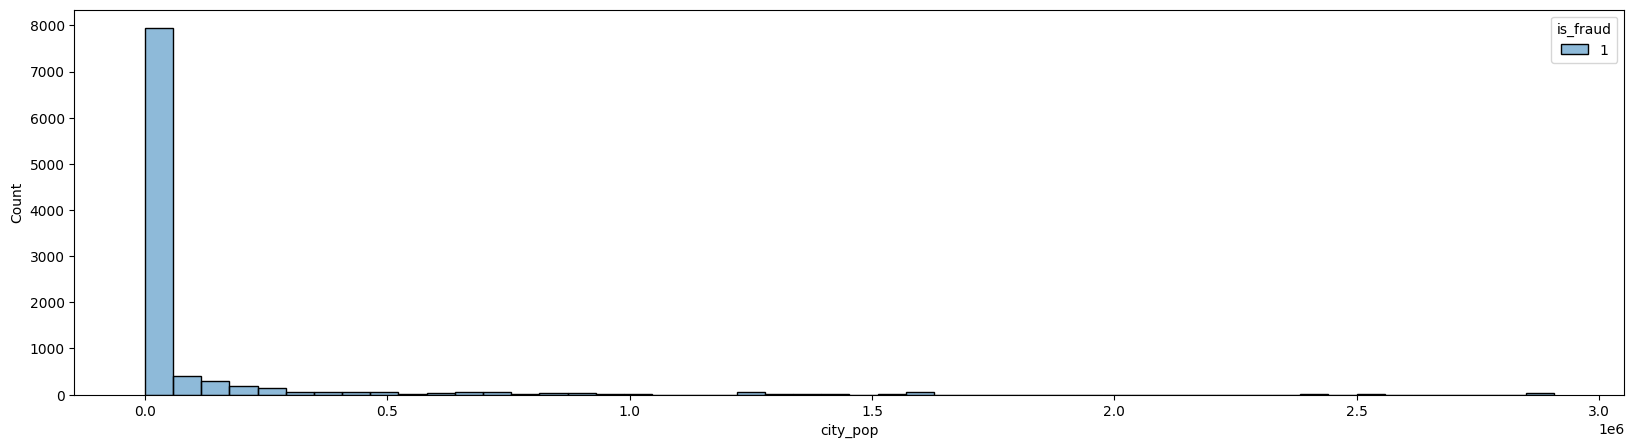

In [34]:
# plt.hist(df_fraud['city_pop'],bins=20)
fig = plt.figure(figsize=(20,5))
sns.histplot(data=df_fraud[df_fraud['is_fraud']==1],x='city_pop',bins=50,hue='is_fraud')
plt.show()

In [35]:
df_fraud[df_fraud['is_fraud']==1]['amt'].describe()

count    9651.000000
mean      530.661412
std       391.028873
min         1.060000
25%       240.075000
50%       390.000000
75%       902.365000
max      1376.040000
Name: amt, dtype: float64

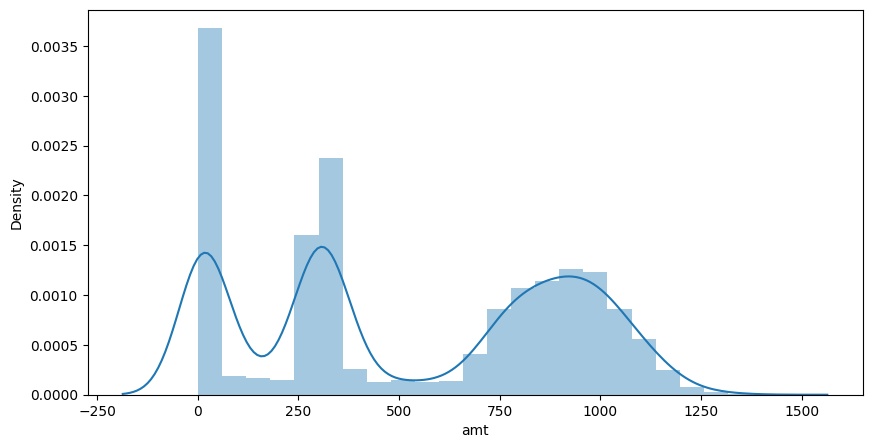

In [36]:
# plt.hist(df_fraud['city_pop'],bins=20)
fig = plt.figure(figsize=(10,5))
# sns.histplot(data=df_fraud[df_fraud['is_fraud']==1],x='amt',bins=30, hue='is_fraud')
sns.distplot(df_fraud[df_fraud['is_fraud']==1]['amt'])
plt.show()

The frauds seem to happen more at lower transcational amount < 100 followed by the ranges of $260 - $275 and $750 - $1000

In [37]:
df_fraud.columns

Index(['Unnamed: 0', 'trans_date_trans_time', 'cc_num', 'merchant', 'category',
       'amt', 'first', 'last', 'gender', 'street', 'city', 'state', 'zip',
       'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time',
       'merch_lat', 'merch_long', 'is_fraud', 'trans_date', 'trans_time'],
      dtype='object')

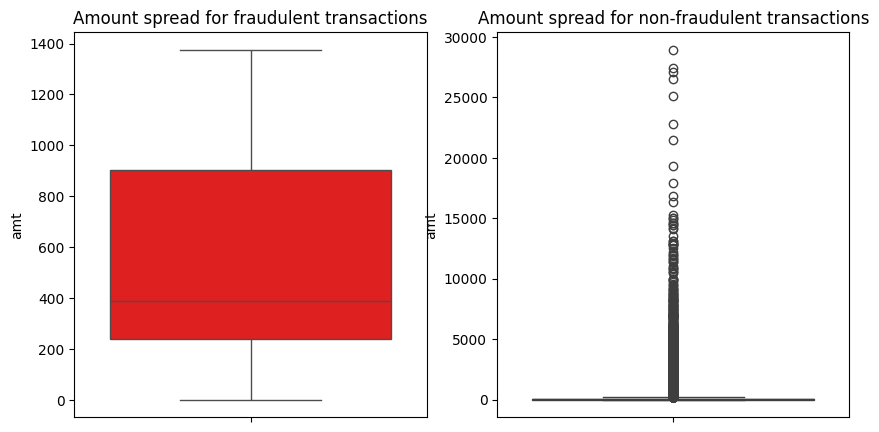

In [38]:
plt.figure(figsize=[10,5])
plt.subplot(1,2,1)
sns.boxplot(df_fraud[df_fraud['is_fraud']==1],y='amt',color='red')
plt.title('Amount spread for fraudulent transactions')
plt.subplot(1,2,2)
sns.boxplot(df_fraud[df_fraud['is_fraud']==0],y='amt')
plt.title('Amount spread for non-fraudulent transactions')
plt.show()

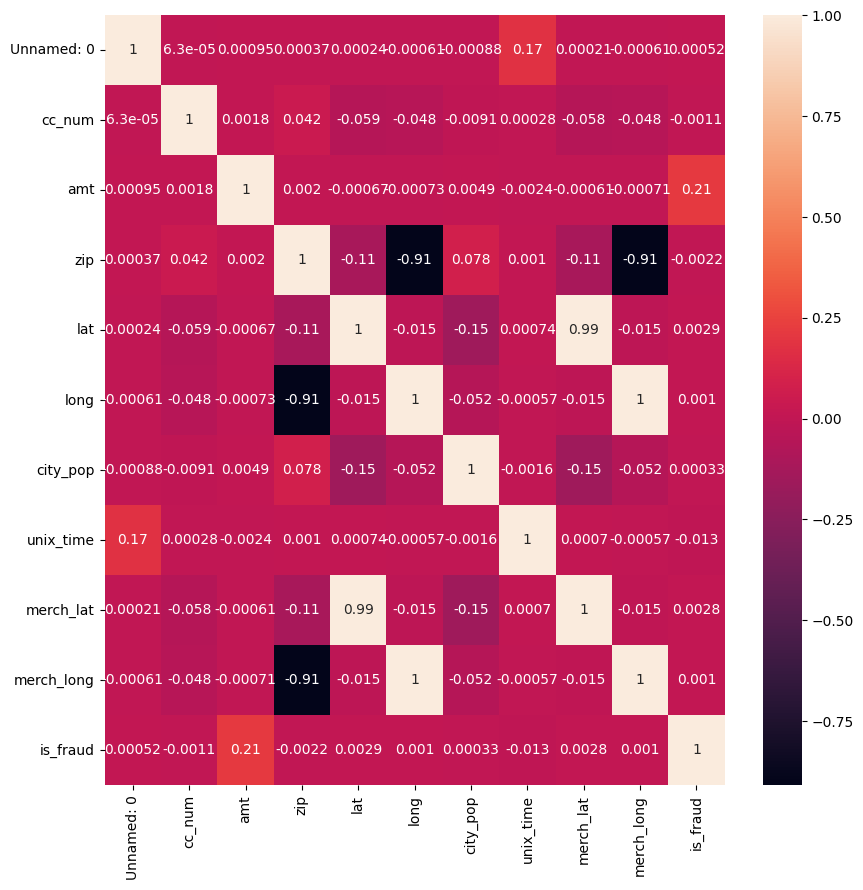

In [39]:
plt.figure(figsize=[10,10])
sns.heatmap(df_fraud.corr(numeric_only=True),annot=True)
plt.show()

## Feature engineering

- age : calculated from dob
- trans_year : calculated from transaction date time
- trans_month : calculated from transaction date time
- trans_date : calculated from transaction date time
- trans_day : calculated from transaction date time
- trans_year_month : calculated from transaction date time

In [40]:
df_fraud['age'] = df_fraud['dob'].apply(lambda x: (pd.Timestamp.now().year - x.year))

In [41]:
df_fraud['trans_year'] = df_fraud['trans_date_trans_time'].dt.year
df_fraud['trans_month'] = df_fraud['trans_date_trans_time'].dt.month
df_fraud['trans_date'] = df_fraud['trans_date_trans_time'].dt.day
df_fraud['trans_day'] = df_fraud['trans_date_trans_time'].dt.day_name()
df_fraud['trans_hr'] = df_fraud['trans_date_trans_time'].dt.hour

In [42]:
df_fraud['year_month']  = df_fraud['trans_year'].astype(str) +'-'+df_fraud['trans_month'].astype(str)

In [43]:
df_fraud.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,merch_long,is_fraud,trans_date,trans_time,age,trans_year,trans_month,trans_day,trans_hr,year_month
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,-82.048315,0,1,00:00:18,37,2019,1,Tuesday,0,2019-1
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,-118.186462,0,1,00:00:44,47,2019,1,Tuesday,0,2019-1
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,-112.154481,0,1,00:00:51,63,2019,1,Tuesday,0,2019-1
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,-112.561071,0,1,00:01:16,58,2019,1,Tuesday,0,2019-1
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,-78.632459,0,1,00:03:06,39,2019,1,Tuesday,0,2019-1


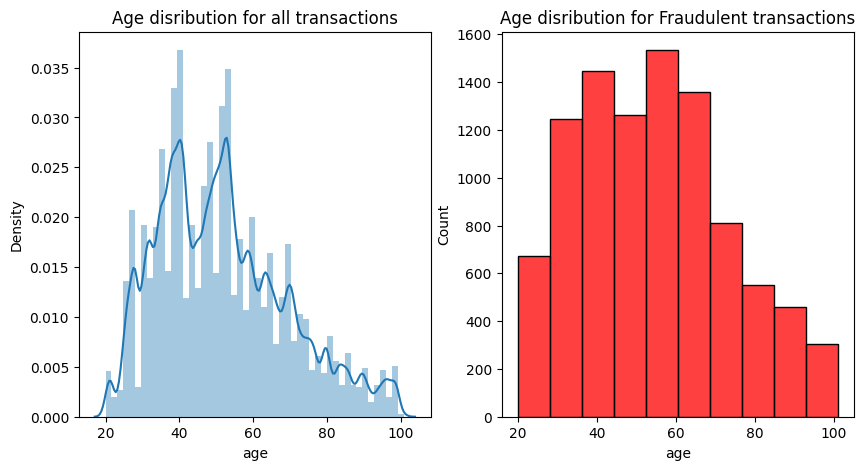

In [44]:
plt.figure(figsize=[10,5])
plt.subplot(1,2,1)
sns.distplot(df_fraud['age'])
plt.title('Age disribution for all transactions')
plt.subplot(1,2,2)
# sns.distplot(df_fraud[df_fraud['is_fraud']==1]['age'])
sns.histplot(data=df_fraud[df_fraud['is_fraud']==1],x='age',bins=10,color='red')
plt.title('Age disribution for Fraudulent transactions')
plt.show()

Customers between the age groups of 50 - 60 and 35 - 45 seem to more impacted by frauds

### Frauds over time

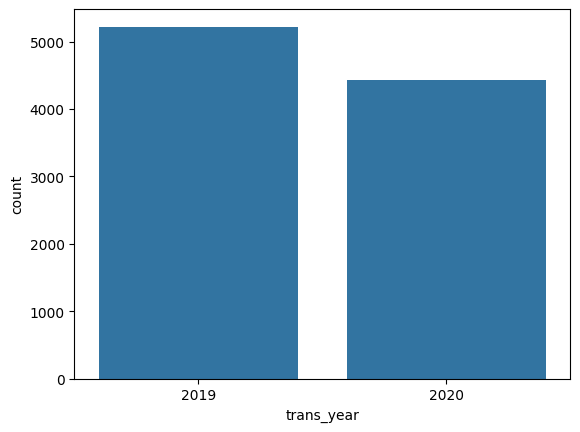

In [45]:
sns.countplot(df_fraud[df_fraud['is_fraud']==1],x='trans_year')
plt.show()

The fraudulent transactions have reduced in 2020 compare the previous year

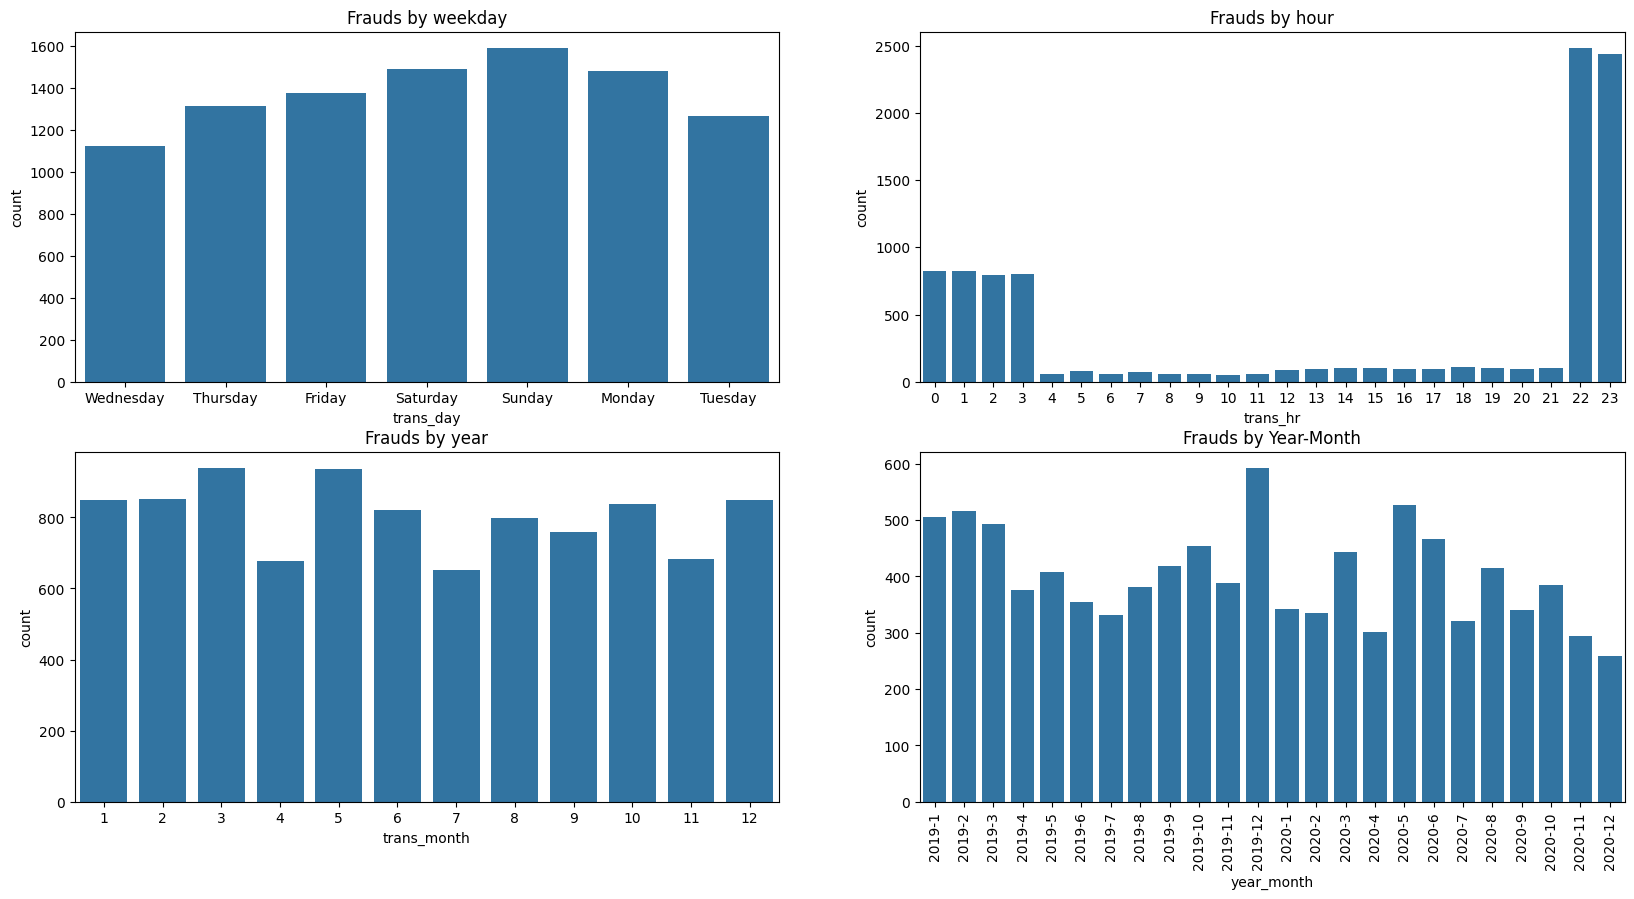

In [46]:
plt.figure(figsize=[20,10])
plt.subplot(2,2,1)
sns.countplot(df_fraud[df_fraud['is_fraud']==1],x='trans_day')
plt.title('Frauds by weekday')
plt.subplot(2,2,2)
sns.countplot(df_fraud[df_fraud['is_fraud']==1],x='trans_hr')
plt.title('Frauds by hour')
plt.subplot(2,2,3)
sns.countplot(df_fraud[df_fraud['is_fraud']==1],x='trans_month')
plt.title('Frauds by year')
plt.subplot(2,2,4)
sns.countplot(df_fraud[df_fraud['is_fraud']==1],x='year_month')
plt.title('Frauds by Year-Month')
plt.xticks(rotation=90)
plt.show()

- More frauds seem to happen on weekends
- Fraudulent transcations seem to happen more in the late hours after 10pm and early morning before 3am
- March, May, Jan and Feb recorded higher frauds
- 2019 December has the highest fradulent transcations followed by 2020 May. This could be due to holiday season

## Cost benefit analysis - Part 1

In [47]:
num_of_months = df_fraud['year_month'].nunique()
num_of_transactions = df_fraud.shape[0]
print(num_of_months,',',num_of_transactions)

24 , 1852394


In [48]:
total_trans_amt = df_fraud['amt'].sum().sum()
total_fraud_trans_amt = df_fraud[df_fraud['is_fraud']==1]['amt'].sum().sum()

num_of_fraud_trans = df_fraud[df_fraud['is_fraud']==1].shape[0]

In [49]:
print(f"> Average transcations per month: {num_of_transactions/num_of_months} ")

print(f"> Average Fraud Transcations per month: {num_of_fraud_trans/num_of_months} ")

print(f"> Average fraud amount per transaction: {total_fraud_trans_amt/num_of_fraud_trans}")


> Average transcations per month: 77183.08333333333 
> Average Fraud Transcations per month: 402.125 
> Average fraud amount per transaction: 530.661412288882


S.No.| Questions| Answer |
---|---|---|
a | Average number of transactions per month | 77183 |
b | Average number of fraudulent transaction per month | 402 |
c | Average amount per fraud transaction | $ 530.67|


In [50]:
df_fraud.columns

Index(['Unnamed: 0', 'trans_date_trans_time', 'cc_num', 'merchant', 'category',
       'amt', 'first', 'last', 'gender', 'street', 'city', 'state', 'zip',
       'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time',
       'merch_lat', 'merch_long', 'is_fraud', 'trans_date', 'trans_time',
       'age', 'trans_year', 'trans_month', 'trans_day', 'trans_hr',
       'year_month'],
      dtype='object')

### Model building approach

- Create dummy variables for columns (category, gender, weekday, month, year)
- Encode state, job, merchant, city, street using label encoder
- drop columns that are unique to each row (cc_num, trans_num, dob, trans_time, trans_date_trans_time, unix_time, zip)
- Split data into train and test
- Sampling the data - SMOTE, ADASYN
- Models
 - Decision Tree
   - Default - SMOTE
   - Default - ADASYN
   - Tuned - SMOTE or ADASYN based on results
 - RandomForest
   - Default - SMOTE
   - Default - ADASYN
   - Tuned - SMOTE or ADASYN based on results
 - XGBoost
   - Default - SMOTE
   - Default - ADASYN
   - Tuned - SMOTE or ADASYN based on results   
 - Evaluate final model on test
 - Calculate cost benefits


## Prepare train data for modelling

### Dummy variables and encoding

In [51]:
df_copy = df_fraud.copy()

In [52]:
cat_dummy = pd.get_dummies(df_fraud['category'],drop_first=True,prefix='cat',dtype='int')
gender_dummy = pd.get_dummies(df_fraud['gender'],drop_first=True,prefix='gender',dtype='int')
weekday_dummy = pd.get_dummies(df_fraud['trans_day'],drop_first=True,prefix='weekday',dtype='int')
month_dummy = pd.get_dummies(df_fraud['trans_month'],drop_first=True,prefix='month',dtype='int')
year_dummy = pd.get_dummies(df_fraud['trans_year'],drop_first=True,prefix='year',dtype='int')
year_month_dummy = pd.get_dummies(df_fraud['year_month'],drop_first=True,prefix='yrmth',dtype='int')

df_fraud = pd.concat([df_fraud,cat_dummy,gender_dummy,weekday_dummy,month_dummy,year_dummy],axis=1)
df_fraud.drop(columns=['category','gender','trans_day','trans_month','trans_year','year_month'],inplace=True)

In [53]:
df_fraud.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,amt,first,last,street,city,state,...,month_4,month_5,month_6,month_7,month_8,month_9,month_10,month_11,month_12,year_2020
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",4.97,Jennifer,Banks,561 Perry Cove,Moravian Falls,NC,...,0,0,0,0,0,0,0,0,0,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",107.23,Stephanie,Gill,43039 Riley Greens Suite 393,Orient,WA,...,0,0,0,0,0,0,0,0,0,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,220.11,Edward,Sanchez,594 White Dale Suite 530,Malad City,ID,...,0,0,0,0,0,0,0,0,0,0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",45.00,Jeremy,White,9443 Cynthia Court Apt. 038,Boulder,MT,...,0,0,0,0,0,0,0,0,0,0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,41.96,Tyler,Garcia,408 Bradley Rest,Doe Hill,VA,...,0,0,0,0,0,0,0,0,0,0


In [54]:
print(f"Unique states: {df_copy['state'].nunique()}")
print(f"Unique cities: {df_copy['city'].nunique()}")
print(f"Unique jobs: {df_copy['job'].nunique()}")
print(f"Unique merchants: {df_copy['merchant'].nunique()}")
print(f"Unique streets: {df_copy['street'].nunique()}")

Unique states: 51
Unique cities: 906
Unique jobs: 497
Unique merchants: 693
Unique streets: 999


Since there are very high number of unique values, to optmize the model we will do a one-shot encoding for these columns

In [55]:
label_encoder = LabelEncoder()

df_fraud['state'] = label_encoder.fit_transform(df_fraud['state'])
df_fraud['city'] = label_encoder.fit_transform(df_fraud['city'])
df_fraud['job'] = label_encoder.fit_transform(df_fraud['job'])
df_fraud['merchant'] = label_encoder.fit_transform(df_fraud['merchant'])
df_fraud['street'] = label_encoder.fit_transform(df_fraud['street'])


In [56]:
df_fraud.shape

(1852394, 57)

In [57]:
df_fraud.drop(columns=['Unnamed: 0','first','last','cc_num', 'trans_num', 'dob', 'trans_time', 'trans_date_trans_time', 'unix_time', 'zip'],inplace=True)

In [58]:
df_fraud.shape

(1852394, 47)

In [59]:
df_fraud.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1852394 entries, 0 to 555718
Data columns (total 47 columns):
 #   Column              Dtype  
---  ------              -----  
 0   merchant            int64  
 1   amt                 float64
 2   street              int64  
 3   city                int64  
 4   state               int64  
 5   lat                 float64
 6   long                float64
 7   city_pop            int64  
 8   job                 int64  
 9   merch_lat           float64
 10  merch_long          float64
 11  is_fraud            int64  
 12  trans_date          int32  
 13  age                 int64  
 14  trans_hr            int32  
 15  cat_food_dining     int64  
 16  cat_gas_transport   int64  
 17  cat_grocery_net     int64  
 18  cat_grocery_pos     int64  
 19  cat_health_fitness  int64  
 20  cat_home            int64  
 21  cat_kids_pets       int64  
 22  cat_misc_net        int64  
 23  cat_misc_pos        int64  
 24  cat_personal_care   int64  
 2

### Split data to train and validation

In [60]:
X = df_fraud.drop(columns=['is_fraud'])

In [61]:
y = df_fraud['is_fraud']

In [62]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

In [63]:
print(f"Train data shape: {X_train.shape}")
print(f"Train label shape: {y_train.shape}")
print(f"Validation data shape: {X_test.shape}")
print(f"Validation label shape: {y_test.shape}")

Train data shape: (1296675, 46)
Train label shape: (1296675,)
Validation data shape: (555719, 46)
Validation label shape: (555719,)


In [64]:
100*y_train.value_counts(normalize=True)

is_fraud
0    99.478975
1     0.521025
Name: proportion, dtype: float64

In [65]:
100*y_test.value_counts(normalize=True)

is_fraud
0    99.479053
1     0.520947
Name: proportion, dtype: float64

### Treating the imbalance through sampling

#### SMOTE

In [66]:
smt = SMOTE(random_state=42, k_neighbors=5)
X_train_smt, y_train_smt = smt.fit_resample(X_train, y_train)

In [67]:
print(f"Train data shape: {X_train_smt.shape}")
print(f"Train label shape: {y_train_smt.shape}")

Train data shape: (2579838, 46)
Train label shape: (2579838,)


In [68]:
100*y_train_smt.value_counts(normalize=True)

is_fraud
0    50.0
1    50.0
Name: proportion, dtype: float64

#### ADASYN

In [69]:
ada = ADASYN(random_state=42, n_neighbors=5)
X_train_ada, y_train_ada = ada.fit_resample(X_train, y_train)

In [70]:
print(f"Train data shape: {X_train_ada.shape}")
print(f"Train label shape: {y_train_ada.shape}")

Train data shape: (2580097, 46)
Train label shape: (2580097,)


In [71]:
100*y_train_ada.value_counts(normalize=True)

is_fraud
1    50.005019
0    49.994981
Name: proportion, dtype: float64

## Modelling

### Model 1 -  Decision Tree

#### Default - SMOTE

In [72]:
dt_default_smt = DecisionTreeClassifier(random_state=42)

In [73]:
dt_default_smt.fit(X_train_smt, y_train_smt)

DecisionTreeClassifier(random_state=42)

In [74]:
y_train_pred_dt_default_smt = dt_default_smt.predict(X_train_smt)
y_test_pred_dt_default_smt = dt_default_smt.predict(X_test)
print(classification_report(y_train_smt, y_train_pred_dt_default_smt))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1289919
           1       1.00      1.00      1.00   1289919

    accuracy                           1.00   2579838
   macro avg       1.00      1.00      1.00   2579838
weighted avg       1.00      1.00      1.00   2579838



##### Evaluate model

ROC for the validation dataset: 87.8%


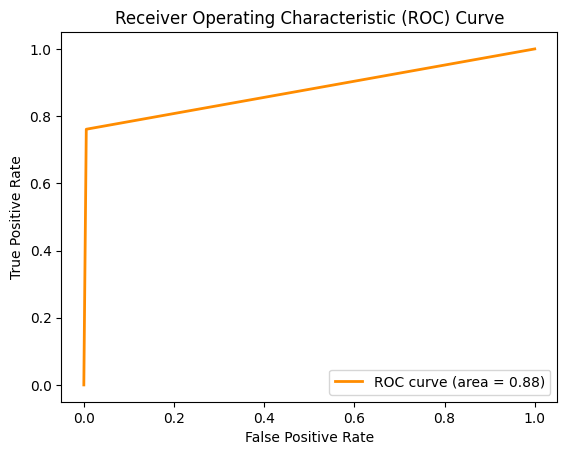

In [75]:
from sklearn import metrics

pred_prob_test = dt_default_smt.predict_proba(X_test)[:,1]
fpr, tpr, threshold = metrics.roc_curve(y_test, pred_prob_test)
roc_auc = metrics.auc(fpr, tpr)
print(f"ROC for the validation dataset: {roc_auc:.1%}")

plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

In [76]:
print(f"Accuracy score: {accuracy_score(y_test, y_test_pred_dt_default_smt):.1%}")
print(f"Precision: {precision_score(y_test, y_test_pred_dt_default_smt):.1%}")
print(f"Recall: {recall_score(y_test, y_test_pred_dt_default_smt):.1%}")
print(f"F1-score: {f1_score(y_test, y_test_pred_dt_default_smt):.1%}")

print("Confusion matrix:")
print(confusion_matrix(y_test, y_test_pred_dt_default_smt))

confusion_dt_smt = confusion_matrix(y_test, y_test_pred_dt_default_smt)

TN = confusion_dt_smt[0, 0]
FP = confusion_dt_smt[0, 1]
FN = confusion_dt_smt[1, 0]
TP = confusion_dt_smt[1, 1]

print(f"Specificity: {TN/float(TN+FP):.1%} ")
print(f"False positive rate: {FP/float(TN+FP):.1%}")
print(f"Sensitivity: {TP/float(TP+FN):.1%} ")
print(f"Positive predictive value: {TP/float(TP+FP):.1%} ")
print(f"Negative predictive value: {TN/float(TN+FN):.1%} ")

Accuracy score: 99.3%
Precision: 42.3%
Recall: 76.1%
F1-score: 54.4%
Confusion matrix:
[[549818   3006]
 [   692   2203]]
Specificity: 99.5% 
False positive rate: 0.5%
Sensitivity: 76.1% 
Positive predictive value: 42.3% 
Negative predictive value: 99.9% 


##### Results

Data |ROC | Accuracy | Precision | Recall | F1-Score | Specificity | FPR |
---|---|---|---|---|---|---|---|
SMOTE | 87.8% | 99.3% | 42.3% | 76.1% | 54.4% | 99.5% | 0.5% |


#### Default - ADASYN

In [77]:
dt_default_ada = DecisionTreeClassifier(random_state=42)

In [78]:
dt_default_ada.fit(X_train_ada, y_train_ada)

DecisionTreeClassifier(random_state=42)

In [79]:
y_train_pred_dt_default_ada = dt_default_ada.predict(X_train_ada)
y_test_pred_dt_default_ada = dt_default_ada.predict(X_test)
print(classification_report(y_train_ada, y_train_pred_dt_default_ada))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1289919
           1       1.00      1.00      1.00   1290178

    accuracy                           1.00   2580097
   macro avg       1.00      1.00      1.00   2580097
weighted avg       1.00      1.00      1.00   2580097



##### Evaluate model

ROC for the validation dataset: 87.2%


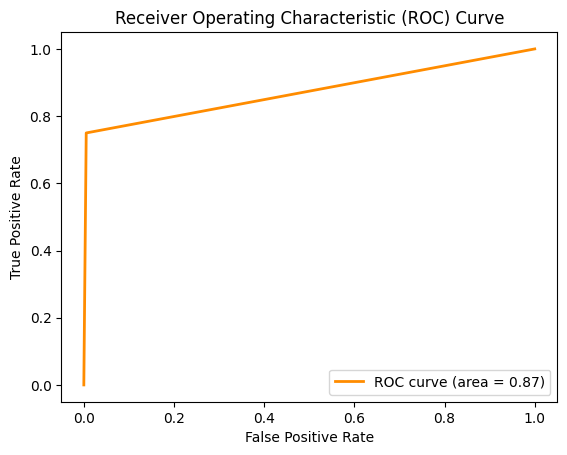

In [80]:
pred_prob_test = dt_default_ada.predict_proba(X_test)[:,1]
fpr, tpr, threshold = metrics.roc_curve(y_test, pred_prob_test)
roc_auc = metrics.auc(fpr, tpr)
print(f"ROC for the validation dataset: {roc_auc:.1%}")
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

In [81]:
print(f"Accuracy score: {accuracy_score(y_test, y_test_pred_dt_default_ada):.1%}")
print(f"Precision: {precision_score(y_test, y_test_pred_dt_default_ada):.1%}")
print(f"Recall: {recall_score(y_test, y_test_pred_dt_default_ada):.1%}")
print(f"F1-score: {f1_score(y_test, y_test_pred_dt_default_ada):.1%}")
print("Confusion matrix:")
print(confusion_matrix(y_test, y_test_pred_dt_default_ada))

confusion_dt_smt = confusion_matrix(y_test, y_test_pred_dt_default_ada)
TN = confusion_dt_smt[0, 0]
FP = confusion_dt_smt[0, 1]
FN = confusion_dt_smt[1, 0]
TP = confusion_dt_smt[1, 1]

print(f"Specificity: {TN/float(TN+FP):.1%} ")
print(f"False positive rate: {FP/float(TN+FP):.1%}")
print(f"Sensitivity: {TP/float(TP+FN):.1%} ")
print(f"Positive predictive value: {TP/float(TP+FP):.1%} ")
print(f"Negative predictive value: {TN/float(TN+FN):.1%} ")

Accuracy score: 99.3%
Precision: 42.5%
Recall: 75.0%
F1-score: 54.3%
Confusion matrix:
[[549890   2934]
 [   724   2171]]
Specificity: 99.5% 
False positive rate: 0.5%
Sensitivity: 75.0% 
Positive predictive value: 42.5% 
Negative predictive value: 99.9% 


##### Results

Data |ROC | Accuracy | Precision | Recall | F1-Score | Specificity | FPR |
---|---|---|---|---|---|---|---|
ADASYN | 87.2% | 99.3% | 42.5% | 75.0% | 54.3% | 99.5% | 0.5% |

#### Decision Tree - Selection

Data |ROC | Accuracy | Precision | Recall | F1-Score | Specificity | FPR |
---|---|---|---|---|---|---|---|
SMOTE | 87.8% | 99.3% | 42.3% | 76.1% | 54.4% | 99.5% | 0.5% |
ADASYN | 87.2% | 99.3% | 42.5% | 75.0% | 54.3% | 99.5% | 0.5% |

As the Decision tree using SMOTE data has a higher recall value, we will take that model and fine tune it


#### DecisionTree hypertuning

In [82]:
dt_default_tuned = DecisionTreeClassifier(random_state=42)

In [83]:
params = {
    'max_depth': [5, 10, 20],
    'min_samples_split': [5, 10, 20],
    'min_samples_leaf': [5, 10, 20],
}

In [84]:
from sklearn.model_selection import GridSearchCV

grid_search = GridSearchCV(estimator=dt_default_tuned, param_grid=params, cv=4, scoring='recall', n_jobs=-1, verbose=1)

In [85]:
%%time
grid_search.fit(X_train_smt, y_train_smt)

Fitting 4 folds for each of 27 candidates, totalling 108 fits
CPU times: user 33.3 s, sys: 1.02 s, total: 34.4 s
Wall time: 4min 24s


GridSearchCV(cv=4, estimator=DecisionTreeClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [5, 10, 20],
                         'min_samples_leaf': [5, 10, 20],
                         'min_samples_split': [5, 10, 20]},
             scoring='recall', verbose=1)

In [86]:
grid_search.best_score_

np.float64(0.992514260005499)

In [87]:
dt_default_best = grid_search.best_estimator_
dt_default_best

DecisionTreeClassifier(max_depth=20, min_samples_leaf=5, min_samples_split=5,
                       random_state=42)

In [88]:
y_train_pred_dt_default_best = dt_default_best.predict(X_train_smt)
y_test_pred_dt_default_best = dt_default_best.predict(X_test)
print(classification_report(y_train_smt, y_train_pred_dt_default_best))

              precision    recall  f1-score   support

           0       0.99      0.97      0.98   1289919
           1       0.97      0.99      0.98   1289919

    accuracy                           0.98   2579838
   macro avg       0.98      0.98      0.98   2579838
weighted avg       0.98      0.98      0.98   2579838



##### Evaluate model

ROC for the validation dataset: 92.9%


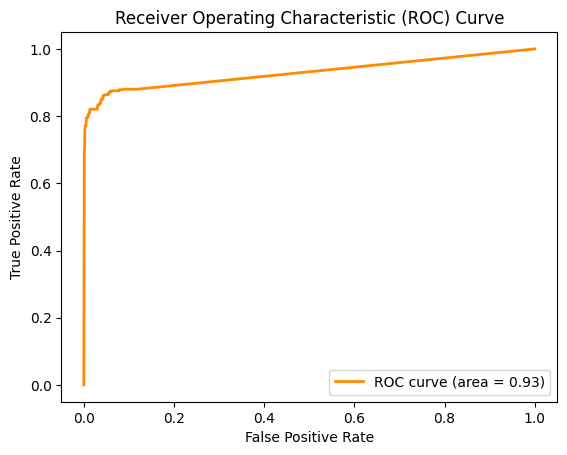

In [89]:
pred_prob_test = dt_default_best.predict_proba(X_test)[:,1]
fpr, tpr, threshold = metrics.roc_curve(y_test, pred_prob_test)
roc_auc = metrics.auc(fpr, tpr)
print(f"ROC for the validation dataset: {roc_auc:.1%}")
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

In [90]:
print(f"Accuracy score: {accuracy_score(y_test, y_test_pred_dt_default_best):.1%}")
print(f"Precision: {precision_score(y_test, y_test_pred_dt_default_best):.1%}")
print(f"Recall: {recall_score(y_test, y_test_pred_dt_default_best):.1%}")
print(f"F1-score: {f1_score(y_test, y_test_pred_dt_default_best):.1%}")
print("Confusion matrix:")
print(confusion_matrix(y_test, y_test_pred_dt_default_best))

confusion_dt_smt = confusion_matrix(y_test, y_test_pred_dt_default_best)
TN = confusion_dt_smt[0, 0]
FP = confusion_dt_smt[0, 1]
FN = confusion_dt_smt[1, 0]
TP = confusion_dt_smt[1, 1]

print(f"Specificity: {TN/float(TN+FP):.1%} ")
print(f"False positive rate: {FP/float(TN+FP):.1%}")
print(f"Sensitivity: {TP/float(TP+FN):.1%} ")
print(f"Positive predictive value: {TP/float(TP+FP):.1%} ")
print(f"Negative predictive value: {TN/float(TN+FN):.1%} ")

Accuracy score: 96.5%
Precision: 11.2%
Recall: 83.4%
F1-score: 19.8%
Confusion matrix:
[[533717  19107]
 [   480   2415]]
Specificity: 96.5% 
False positive rate: 3.5%
Sensitivity: 83.4% 
Positive predictive value: 11.2% 
Negative predictive value: 99.9% 


##### Results

Data | ROC| Accuracy | Precision | Recall | F1-Score | Specificity | FPR |
---|---|---|---|---|---|---|---|
SMOTE | 87.8% | 99.3% | 42.3% | 76.1% | 54.4% | 99.5% | 0.5% |
ADASYN | 87.2% | 99.3% | 42.5% | 75.0% | 54.3% | 99.5% | 0.5% |
Tuned | 92.9% |96.5% | 11.2% | 83.4% | 19.8% | 96.5% | 3.5% |

Params for the best hypertuned Decision Tree

- max_depth = 20
- min_samples_leaf = 5
- min_samples_split = 5
- random_state = 42

#### Decision Tree - Results

Data | ROC| Accuracy | Precision | Recall | F1-Score | Specificity | FPR |
---|---|---|---|---|---|---|---|
Tuned | 92.9% |96.5% | 11.2% | 83.4% | 19.8% | 96.5% | 3.5% |

### Model 2 -  RandomForest

#### RandomForest - SMOTE

In [91]:
rf_default_smt = RandomForestClassifier(random_state=42, oob_score=True)

In [92]:
rf_default_smt.fit(X_train_smt, y_train_smt)

RandomForestClassifier(oob_score=True, random_state=42)

In [93]:
rf_default_smt.oob_score_

0.9989654389151567

In [94]:
y_train_pred_rf_default_smt = rf_default_smt.predict(X_train_smt)
y_test_pred_rf_default_smt = rf_default_smt.predict(X_test)
print(classification_report(y_train_smt, y_train_pred_rf_default_smt))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1289919
           1       1.00      1.00      1.00   1289919

    accuracy                           1.00   2579838
   macro avg       1.00      1.00      1.00   2579838
weighted avg       1.00      1.00      1.00   2579838



##### Evaluate model

ROC for the validation dataset: 99.3%


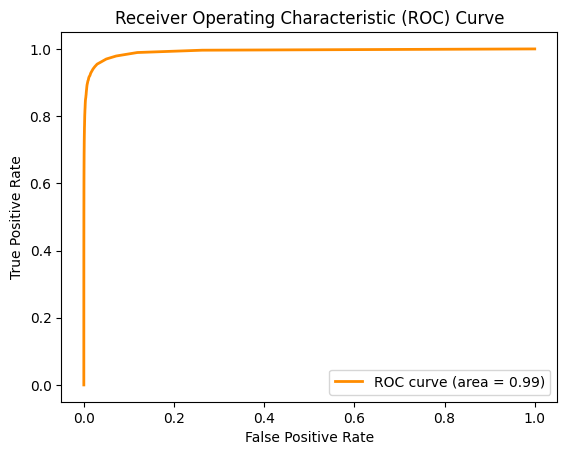

In [95]:
pred_prob_test = rf_default_smt.predict_proba(X_test)[:,1]
fpr, tpr, threshold = metrics.roc_curve(y_test, pred_prob_test)
roc_auc = metrics.auc(fpr, tpr)
print(f"ROC for the validation dataset: {roc_auc:.1%}")

plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

In [96]:
print(f"Accuracy score: {accuracy_score(y_test, y_test_pred_rf_default_smt):.1%}")
print(f"Precision: {precision_score(y_test, y_test_pred_rf_default_smt):.1%}")
print(f"Recall: {recall_score(y_test, y_test_pred_rf_default_smt):.1%}")
print(f"F1-score: {f1_score(y_test, y_test_pred_rf_default_smt):.1%}")

print("Confusion matrix:")
print(confusion_matrix(y_test, y_test_pred_rf_default_smt))

confusion_dt_smt = confusion_matrix(y_test, y_test_pred_rf_default_smt)

TN = confusion_dt_smt[0, 0]
FP = confusion_dt_smt[0, 1]
FN = confusion_dt_smt[1, 0]
TP = confusion_dt_smt[1, 1]

print(f"Specificity: {TN/float(TN+FP):.1%} ")
print(f"False positive rate: {FP/float(TN+FP):.1%}")
print(f"Sensitivity: {TP/float(TP+FN):.1%} ")
print(f"Positive predictive value: {TP/float(TP+FP):.1%} ")
print(f"Negative predictive value: {TN/float(TN+FN):.1%} ")


Accuracy score: 99.8%
Precision: 81.2%
Recall: 71.8%
F1-score: 76.2%
Confusion matrix:
[[552344    480]
 [   817   2078]]
Specificity: 99.9% 
False positive rate: 0.1%
Sensitivity: 71.8% 
Positive predictive value: 81.2% 
Negative predictive value: 99.9% 


##### Results

Data | ROC| Accuracy | Precision | Recall | F1-Score | Specificity | FPR |
---|---|---|---|---|---|---|---|
SMOTE | 99.3% | 99.8% | 81.2% | 71.8% | 76.2% | 99.9% | 0.1% |

#### RandomForest - ADASYN

In [97]:
rf_default_ada = RandomForestClassifier(random_state=42, oob_score=True)

In [98]:
rf_default_ada.fit(X_train_ada, y_train_ada)

RandomForestClassifier(oob_score=True, random_state=42)

In [99]:
rf_default_ada.oob_score_

0.9989589538687886

In [100]:
y_train_pred_rf_default_ada = rf_default_ada.predict(X_train_ada)
y_test_pred_rf_default_ada = rf_default_ada.predict(X_test)
print(classification_report(y_train_ada, y_train_pred_rf_default_ada))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1289919
           1       1.00      1.00      1.00   1290178

    accuracy                           1.00   2580097
   macro avg       1.00      1.00      1.00   2580097
weighted avg       1.00      1.00      1.00   2580097



##### Evaluate model

ROC for the validation dataset: 99.3%


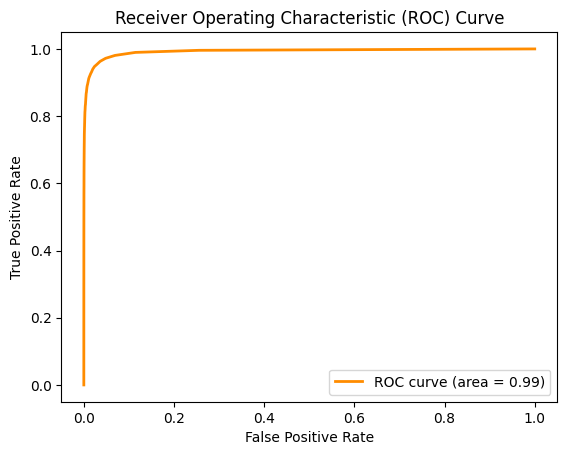

In [101]:
pred_prob_test = rf_default_ada.predict_proba(X_test)[:,1]
fpr, tpr, threshold = metrics.roc_curve(y_test, pred_prob_test)
roc_auc = metrics.auc(fpr, tpr)
print(f"ROC for the validation dataset: {roc_auc:.1%}")

plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

In [102]:
print(f"Accuracy score: {accuracy_score(y_test, y_test_pred_rf_default_ada):.1%}")
print(f"Precision: {precision_score(y_test, y_test_pred_rf_default_ada):.1%}")
print(f"Recall: {recall_score(y_test, y_test_pred_rf_default_ada):.1%}")
print(f"F1-score: {f1_score(y_test, y_test_pred_rf_default_ada):.1%}")

print("Confusion matrix:")
print(confusion_matrix(y_test, y_test_pred_rf_default_ada))

confusion_dt_smt = confusion_matrix(y_test, y_test_pred_rf_default_ada)

TN = confusion_dt_smt[0, 0]
FP = confusion_dt_smt[0, 1]
FN = confusion_dt_smt[1, 0]
TP = confusion_dt_smt[1, 1]

print(f"Specificity: {TN/float(TN+FP):.1%} ")
print(f"False positive rate: {FP/float(TN+FP):.1%}")
print(f"Sensitivity: {TP/float(TP+FN):.1%} ")
print(f"Positive predictive value: {TP/float(TP+FP):.1%} ")
print(f"Negative predictive value: {TN/float(TN+FN):.1%} ")


Accuracy score: 99.8%
Precision: 81.0%
Recall: 70.8%
F1-score: 75.6%
Confusion matrix:
[[552344    480]
 [   844   2051]]
Specificity: 99.9% 
False positive rate: 0.1%
Sensitivity: 70.8% 
Positive predictive value: 81.0% 
Negative predictive value: 99.8% 


##### Results

Data | ROC| Accuracy | Precision | Recall | F1-Score | Specificity | FPR |
---|---|---|---|---|---|---|---|
ADASYN | 99.3% |99.8% | 81.0% | 70.8% | 75.6% | 99.9% | 0.1% |

#### RandomForest Selection

Data | ROC| Accuracy | Precision | Recall | F1-Score | Specificity | FPR |
---|---|---|---|---|---|---|---|
SMOTE | 99.3% | 99.8% | 81.2% | 71.8% | 76.2% | 99.9% | 0.1% |
ADASYN | 99.3% |99.8% | 81.0% | 70.8% | 75.6% | 99.9% | 0.1% |

As the RandomForest using SMOTE data has a higher recall value, we will take that model and finetune it

#### RandomForeset hypertuning

In [103]:
rf_tuned = RandomForestClassifier(random_state=42, oob_score=True)

In [104]:
params = {
    'max_depth': [5, 10, 15, 20],
    'min_samples_split': [5, 10],
    'min_samples_leaf': [5, 10],
    'n_estimators': [5,10],
}

In [105]:
from sklearn.model_selection import RandomizedSearchCV

Randomized_search = RandomizedSearchCV(
    estimator=rf_tuned,
    param_distributions=params,
    n_iter=32,
    scoring='recall',
    cv=4,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

In [106]:
%%time
Randomized_search.fit(X_train_smt, y_train_smt)

Fitting 4 folds for each of 32 candidates, totalling 128 fits


/Users/imthepooh/Documents/Source/py_capstone/venv/lib/python3.13/site-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/Users/imthepooh/Documents/Source/py_capstone/venv/lib/python3.13/site-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/Users/imthepooh/Documents/Source/py_capstone/venv/lib/python3.13/site-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/Users/imthepooh/Documents/Source/py_capstone/venv/lib/python3.13/site-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimat

CPU times: user 37.8 s, sys: 1.83 s, total: 39.6 s
Wall time: 4min 56s


RandomizedSearchCV(cv=4,
                   estimator=RandomForestClassifier(oob_score=True,
                                                    random_state=42),
                   n_iter=32, n_jobs=-1,
                   param_distributions={'max_depth': [5, 10, 15, 20],
                                        'min_samples_leaf': [5, 10],
                                        'min_samples_split': [5, 10],
                                        'n_estimators': [5, 10]},
                   random_state=42, scoring='recall', verbose=1)

In [107]:
rf_score_df = pd.DataFrame(Randomized_search.cv_results_)
rf_score_df.head(4)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_n_estimators,param_min_samples_split,param_min_samples_leaf,param_max_depth,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,mean_test_score,std_test_score,rank_test_score
0,14.093651,0.122255,0.279868,0.024461,5,5,5,5,"{'n_estimators': 5, 'min_samples_split': 5, 'm...",0.738384,0.739751,0.740101,0.741875,0.740028,0.001245,25
1,20.844504,0.253234,0.323565,0.072731,10,5,5,5,"{'n_estimators': 10, 'min_samples_split': 5, '...",0.738750,0.739550,0.739313,0.740477,0.739522,0.000623,29
2,13.844130,0.217933,0.296468,0.038023,5,10,5,5,"{'n_estimators': 5, 'min_samples_split': 10, '...",0.738384,0.739751,0.740101,0.741875,0.740028,0.001245,25
3,20.194532,0.856394,0.405039,0.089202,10,10,5,5,"{'n_estimators': 10, 'min_samples_split': 10, ...",0.738750,0.739550,0.739313,0.740477,0.739522,0.000623,29


In [108]:
Randomized_search.best_score_

np.float64(0.9833718251926441)

In [109]:
rf_tuned_best = Randomized_search.best_estimator_
rf_tuned_best

RandomForestClassifier(max_depth=20, min_samples_leaf=5, min_samples_split=5,
                       n_estimators=10, oob_score=True, random_state=42)

Params for the best hypertuned RandomForest

- max_depth = 20
- min_samples_leaf = 5
- min_samples_split = 5
- n_estimators = 10
- random_state = 42

In [110]:
y_train_pred_rf_tuned_best = rf_tuned_best.predict(X_train_smt)
y_test_pred_rf_tuned_best = rf_tuned_best.predict(X_test)
print(classification_report(y_train_smt, y_train_pred_rf_tuned_best))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99   1289919
           1       0.99      0.99      0.99   1289919

    accuracy                           0.99   2579838
   macro avg       0.99      0.99      0.99   2579838
weighted avg       0.99      0.99      0.99   2579838



##### Evaluate model

ROC for the validation dataset: 96.5%


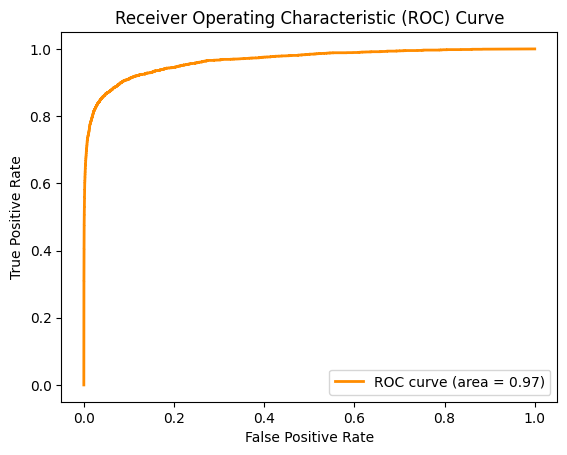

In [111]:
pred_prob_test = rf_tuned_best.predict_proba(X_test)[:,1]
fpr, tpr, threshold = metrics.roc_curve(y_test, pred_prob_test)
roc_auc = metrics.auc(fpr, tpr)
print(f"ROC for the validation dataset: {roc_auc:.1%}")

plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

In [112]:
print(f"Accuracy score: {accuracy_score(y_test, y_test_pred_rf_tuned_best):.1%}")
print(f"Precision: {precision_score(y_test, y_test_pred_rf_tuned_best):.1%}")
print(f"Recall: {recall_score(y_test, y_test_pred_rf_tuned_best):.1%}")
print(f"F1-score: {f1_score(y_test, y_test_pred_rf_tuned_best):.1%}")

print("Confusion matrix:")
print(confusion_matrix(y_test, y_test_pred_rf_tuned_best))

confusion_dt_smt = confusion_matrix(y_test, y_test_pred_rf_tuned_best)

TN = confusion_dt_smt[0, 0]
FP = confusion_dt_smt[0, 1]
FN = confusion_dt_smt[1, 0]
TP = confusion_dt_smt[1, 1]

print(f"Specificity: {TN/float(TN+FP):.1%} ")
print(f"False positive rate: {FP/float(TN+FP):.1%}")
print(f"Sensitivity: {TP/float(TP+FN):.1%} ")
print(f"Positive predictive value: {TP/float(TP+FP):.1%} ")
print(f"Negative predictive value: {TN/float(TN+FN):.1%} ")


Accuracy score: 98.6%
Precision: 24.0%
Recall: 76.8%
F1-score: 36.5%
Confusion matrix:
[[545779   7045]
 [   673   2222]]
Specificity: 98.7% 
False positive rate: 1.3%
Sensitivity: 76.8% 
Positive predictive value: 24.0% 
Negative predictive value: 99.9% 


### Random forest - Results

Data | ROC| Accuracy | Precision | Recall | F1-Score | Specificity | FPR |
---|---|---|---|---|---|---|---|
SMOTE | 99.3% | 99.8% | 81.2% | 71.8% | 76.2% | 99.9% | 0.1% |
ADASYN | 99.3% |99.8% | 81.0% | 70.8% | 75.6% | 99.9% | 0.1% |
Tuned | 96.5% |98.6% | 24.0% | 76.8% | 36.5% | 98.7% |1.3% |

### Model 3 - XGBoost

#### XGBoost - SMOTE

In [113]:
xgb_default_smt = XGBClassifier(random_state=42)

In [114]:
xgb_default_smt.fit(X_train_smt, y_train_smt)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [115]:
y_train_pred_xgb_smt = xgb_default_smt.predict(X_train_smt)
y_test_pred_xgb_smt = xgb_default_smt.predict(X_test)
print(classification_report(y_train_smt, y_train_pred_xgb_smt))

              precision    recall  f1-score   support

           0       1.00      0.99      1.00   1289919
           1       0.99      1.00      1.00   1289919

    accuracy                           1.00   2579838
   macro avg       1.00      1.00      1.00   2579838
weighted avg       1.00      1.00      1.00   2579838



##### Evaluate model

ROC for the validation dataset: 99.3%


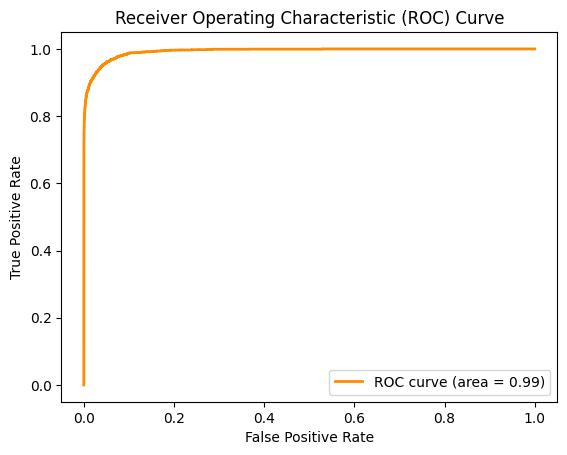

In [116]:
pred_prob_test = xgb_default_smt.predict_proba(X_test)[:,1]
fpr, tpr, threshold = metrics.roc_curve(y_test, pred_prob_test)
roc_auc = metrics.auc(fpr, tpr)
print(f"ROC for the validation dataset: {roc_auc:.1%}")

plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

In [117]:
print(f"Accuracy score: {accuracy_score(y_test, y_test_pred_xgb_smt):.1%}")
print(f"Precision: {precision_score(y_test, y_test_pred_xgb_smt):.1%}")
print(f"Recall: {recall_score(y_test, y_test_pred_xgb_smt):.1%}")
print(f"F1-score: {f1_score(y_test, y_test_pred_xgb_smt):.1%}")

print("Confusion matrix:")
print(confusion_matrix(y_test, y_test_pred_xgb_smt))

confusion_dt_smt = confusion_matrix(y_test, y_test_pred_xgb_smt)

TN = confusion_dt_smt[0, 0]
FP = confusion_dt_smt[0, 1]
FN = confusion_dt_smt[1, 0]
TP = confusion_dt_smt[1, 1]

print(f"Specificity: {TN/float(TN+FP):.1%} ")
print(f"False positive rate: {FP/float(TN+FP):.1%}")
print(f"Sensitivity: {TP/float(TP+FN):.1%} ")
print(f"Positive predictive value: {TP/float(TP+FP):.1%} ")
print(f"Negative predictive value: {TN/float(TN+FN):.1%} ")


Accuracy score: 99.1%
Precision: 36.7%
Recall: 87.4%
F1-score: 51.7%
Confusion matrix:
[[548453   4371]
 [   365   2530]]
Specificity: 99.2% 
False positive rate: 0.8%
Sensitivity: 87.4% 
Positive predictive value: 36.7% 
Negative predictive value: 99.9% 


##### Results

Data | ROC| Accuracy | Precision | Recall | F1-Score | Specificity | FPR |
---|---|---|---|---|---|---|---|
SMOTE | 99.3% | 99.1% | 36.7% | 87.4% | 51.7% | 99.2% | 0.8% |

#### XGBoost - ADASYN

In [118]:
xgb_default_ada = XGBClassifier(random_state=42)

In [119]:
xgb_default_ada.fit(X_train_ada, y_train_ada)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [120]:
y_train_pred_xgb_ada = xgb_default_ada.predict(X_train_ada)
y_test_pred_xgb_ada = xgb_default_ada.predict(X_test)
print(classification_report(y_train_ada, y_train_pred_xgb_ada))

              precision    recall  f1-score   support

           0       1.00      0.99      0.99   1289919
           1       0.99      1.00      0.99   1290178

    accuracy                           0.99   2580097
   macro avg       0.99      0.99      0.99   2580097
weighted avg       0.99      0.99      0.99   2580097



##### Evaluate model

ROC for the validation dataset: 99.3%


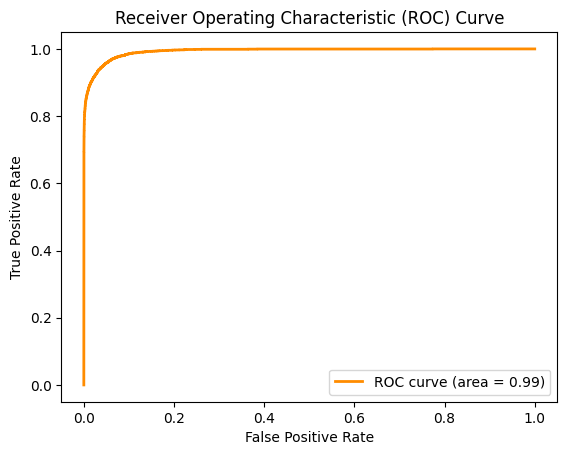

In [121]:
pred_prob_test = xgb_default_ada.predict_proba(X_test)[:,1]
fpr, tpr, threshold = metrics.roc_curve(y_test, pred_prob_test)
roc_auc = metrics.auc(fpr, tpr)
print(f"ROC for the validation dataset: {roc_auc:.1%}")

plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

In [122]:
print(f"Accuracy score: {accuracy_score(y_test, y_test_pred_xgb_ada):.1%}")
print(f"F1-score: {f1_score(y_test, y_test_pred_xgb_ada):.1%}")
print(f"Precision: {precision_score(y_test, y_test_pred_xgb_ada):.1%}")
print(f"Recall: {recall_score(y_test, y_test_pred_xgb_ada):.1%}")

print("Confusion matrix:")
print(confusion_matrix(y_test, y_test_pred_xgb_ada))

confusion_dt_smt = confusion_matrix(y_test, y_test_pred_xgb_ada)

TN = confusion_dt_smt[0, 0]
FP = confusion_dt_smt[0, 1]
FN = confusion_dt_smt[1, 0]
TP = confusion_dt_smt[1, 1]

print(f"Sensitivity: {TP/float(TP+FN):.1%} ")
print(f"Specificity: {TN/float(TN+FP):.1%} ")
print(f"False positive rate: {FP/float(TN+FP):.1%}")
print(f"Positive predictive value: {TP/float(TP+FP):.1%} ")
print(f"Negative predictive value: {TN/float(TN+FN):.1%} ")


Accuracy score: 99.1%
F1-score: 49.8%
Precision: 34.8%
Recall: 87.3%
Confusion matrix:
[[548094   4730]
 [   367   2528]]
Sensitivity: 87.3% 
Specificity: 99.1% 
False positive rate: 0.9%
Positive predictive value: 34.8% 
Negative predictive value: 99.9% 


##### Results

Data | ROC| Accuracy | Precision | Recall | F1-Score | Specificity | FPR |
---|---|---|---|---|---|---|---|
ADASYN | 99.3% | 99.1% | 34.8% | 87.3% | 49.8% | 99.1% | 0.9% |

#### XGBoost Default - Selection

Data | ROC| Accuracy | Precision | Recall | F1-Score | Specificity | FPR |
---|---|---|---|---|---|---|---|
SMOTE | 99.3% | 99.1% | 36.7% | 87.4% | 51.7% | 99.2% | 0.8% |
ADASYN | 99.3% | 99.1% | 34.8% | 87.3% | 49.8% | 99.1% | 0.9% |


As the XGBoost using SMOTE data has a higher recall value, we will take that model and finetune it

#### XGBoost hypertuning

In [123]:
folds = 3

param_grid = {
    'learning_rate': [0.2, 0.6],
    'subsample': [0.3, 0.6, 0.9],
    'max_depth': [2, 5, 10],
    'n_estimators': [50,100],
}

In [124]:
xgb_tuned = XGBClassifier(random_state=42,objective='binary:logistic')

In [125]:
xgb_grid_search = GridSearchCV(
    estimator=xgb_tuned,
    param_grid=param_grid,
    scoring='recall',
    n_jobs=-1,
    cv=folds,
    verbose=1,
    return_train_score=True
)

In [126]:
xgb_grid_search.fit(X_train_smt, y_train_smt)

Fitting 3 folds for each of 36 candidates, totalling 108 fits


GridSearchCV(cv=3,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False, eval_metric=None,
                                     feature_types=None, feature_weights=None,
                                     gamma=None, grow_policy=None,
                                     importance_type=None,
                                     interaction_constraints=Non...
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'learning_rate': [0.2, 0.6], 'max_depth': [2, 5, 10],
                         'n_estimators': [50, 100],
                         'subsample': [0.3, 0.6, 0.9]},
             return_train_score=True, scoring='recall', verbose=1)

In [127]:
grid_results_df = pd.DataFrame(xgb_grid_search.cv_results_)
grid_results_df.head(5)


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_learning_rate,param_max_depth,param_n_estimators,param_subsample,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score,split0_train_score,split1_train_score,split2_train_score,mean_train_score,std_train_score
0,9.883277,0.221578,0.693774,0.216693,0.2,2,50,0.3,"{'learning_rate': 0.2, 'max_depth': 2, 'n_esti...",0.881897,0.880337,0.885951,0.882728,0.002366,34,0.883649,0.880053,0.884581,0.882761,0.001952
1,10.238710,0.103664,1.035623,0.085776,0.2,2,50,0.6,"{'learning_rate': 0.2, 'max_depth': 2, 'n_esti...",0.880583,0.881388,0.882746,0.881572,0.000893,35,0.882290,0.881310,0.881432,0.881677,0.000436
2,9.672946,0.170816,0.510386,0.117083,0.2,2,50,0.9,"{'learning_rate': 0.2, 'max_depth': 2, 'n_esti...",0.880076,0.881006,0.882434,0.881172,0.000970,36,0.882037,0.880813,0.881209,0.881353,0.000510
3,13.110586,0.081439,0.976652,0.023169,0.2,2,100,0.3,"{'learning_rate': 0.2, 'max_depth': 2, 'n_esti...",0.952632,0.950550,0.953471,0.952218,0.001228,33,0.954479,0.948963,0.952596,0.952012,0.002289
4,12.102540,0.085714,0.849120,0.130159,0.2,2,100,0.6,"{'learning_rate': 0.2, 'max_depth': 2, 'n_esti...",0.950697,0.954060,0.953983,0.952913,0.001568,32,0.952996,0.952490,0.953497,0.952994,0.000411


In [128]:
grid_results_df[grid_results_df['rank_test_score']==1]

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_learning_rate,param_max_depth,param_n_estimators,param_subsample,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score,split0_train_score,split1_train_score,split2_train_score,mean_train_score,std_train_score
35,19.495928,0.681239,2.232799,0.032438,0.6,10,100,0.9,"{'learning_rate': 0.6, 'max_depth': 10, 'n_est...",0.998656,0.999995,0.999993,0.999548,0.000631,1,1.0,1.0,0.999999,1.0,5.481792e-07


In [129]:
xgb_grid_search.best_score_

np.float64(0.9995480336362205)

In [130]:
xgb_tuned_best = xgb_grid_search.best_estimator_
xgb_tuned_best

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.6, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=10,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, ...)

In [131]:
y_train_pred_xgb_best_smt = xgb_tuned_best.predict(X_train_smt)
y_test_pred_xgb_best_smt = xgb_tuned_best.predict(X_test)
print(classification_report(y_train_smt, y_train_pred_xgb_best_smt))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1289919
           1       1.00      1.00      1.00   1289919

    accuracy                           1.00   2579838
   macro avg       1.00      1.00      1.00   2579838
weighted avg       1.00      1.00      1.00   2579838



##### Evaluation

ROC for the validation dataset: 99.7%


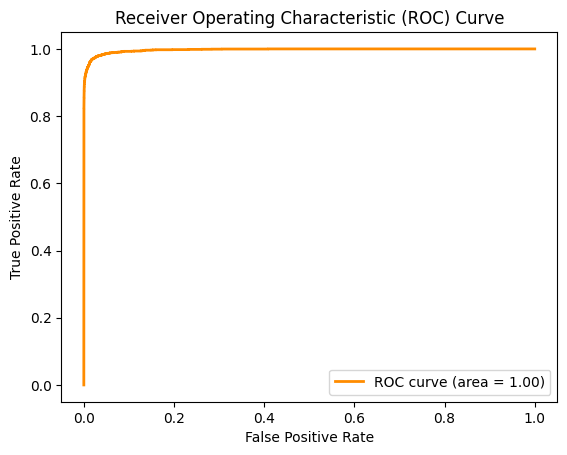

In [132]:
pred_prob_test = xgb_tuned_best.predict_proba(X_test)[:,1]
fpr, tpr, threshold = metrics.roc_curve(y_test, pred_prob_test)
roc_auc = metrics.auc(fpr, tpr)
print(f"ROC for the validation dataset: {roc_auc:.1%}")

plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

In [133]:
print(f"Accuracy score: {accuracy_score(y_test, y_test_pred_xgb_best_smt):.1%}")
print(f"Precision: {precision_score(y_test, y_test_pred_xgb_best_smt):.1%}")
print(f"Recall: {recall_score(y_test, y_test_pred_xgb_best_smt):.1%}")
print(f"F1-score: {f1_score(y_test, y_test_pred_xgb_best_smt):.1%}")

print("Confusion matrix:")
print(confusion_matrix(y_test, y_test_pred_xgb_best_smt))

confusion_dt_smt = confusion_matrix(y_test, y_test_pred_xgb_best_smt)

TN = confusion_dt_smt[0, 0]
FP = confusion_dt_smt[0, 1]
FN = confusion_dt_smt[1, 0]
TP = confusion_dt_smt[1, 1]

print(f"Specificity: {TN/float(TN+FP):.1%} ")
print(f"False positive rate: {FP/float(TN+FP):.1%}")
print(f"Sensitivity: {TP/float(TP+FN):.1%} ")
print(f"Positive predictive value: {TP/float(TP+FP):.1%} ")
print(f"Negative predictive value: {TN/float(TN+FN):.1%} ")


Accuracy score: 99.9%
Precision: 87.6%
Recall: 87.1%
F1-score: 87.3%
Confusion matrix:
[[552466    358]
 [   374   2521]]
Specificity: 99.9% 
False positive rate: 0.1%
Sensitivity: 87.1% 
Positive predictive value: 87.6% 
Negative predictive value: 99.9% 


In [134]:
imp_features_df = pd.DataFrame({
    'Varname':X_train_smt.columns,
    'Imp': xgb_tuned_best.feature_importances_,
    })

In [135]:
imp_features_df.sort_values(by='Imp',ascending=False).head(10)

,Varname,Imp
19,cat_home,0.072223
1,amt,0.066434
14,cat_food_dining,0.064623
18,cat_health_fitness,0.059707
16,cat_grocery_net,0.058833
33,weekday_Wednesday,0.057954
24,cat_shopping_net,0.056881
22,cat_misc_pos,0.056550
25,cat_shopping_pos,0.051440
17,cat_grocery_pos,0.046600


#### XGBoost - Results

The final model selected is the XGBoost model tune with the following hypeparameters

Params
- learning_rate: 0.6
- max_depth: 10
- n_estimators: 100
- subsample: 0.9
- objective: binary:logistic

Data | ROC| Accuracy | Precision | Recall | F1-Score | Specificity | FPR |
---|---|---|---|---|---|---|---|
SMOTE | 99.3% | 99.1% | 36.7% | 87.4% | 51.7% | 99.2% | 0.8% |
ADASYN | 99.3% | 99.1% | 34.8% | 87.3% | 49.8% | 99.1% | 0.9% |
Tuned| 99.7% | 99.9% | 87.6% | 87.1% | 87.3% | 99.9% | 0.1% |


### Cost Benefits after the model - Part 2

In [136]:
print('Confusion matrix on train data')
print(confusion_matrix(y_train_smt, y_train_pred_xgb_best_smt))
# tn, fp, fn, tp = confusion_matrix(y_train_smt, y_train_pred_xgb_best_smt).ravel()
cm = confusion_matrix(y_train_smt, y_train_pred_xgb_best_smt)
tn = cm[0, 0]
fp = cm[0, 1]
fn = cm[1, 0]
tp = cm[1, 1]

print(f'True Negative: {tn}')
print(f'False Positive: {fp}')
print(f'False Negative: {fn}')
print(f'True Positive: {tp}')
print('-----')
print('Confusion matrix on test data')
print(confusion_matrix(y_test, y_test_pred_xgb_best_smt))
# tn, fp, fn, tp = confusion_matrix(y_test, y_test_pred_xgb_best_smt).ravel()
cm =  confusion_matrix(y_test, y_test_pred_xgb_best_smt)
tn = cm[0, 0]
fp = cm[0, 1]
fn = cm[1, 0]
tp = cm[1, 1]
print(f'True Negative: {tn}')
print(f'False Positive: {fp}')
print(f'False Negative: {fn}')
print(f'True Positive: {tp}')


Confusion matrix on train data
[[1289914       5]
 [      1 1289918]]
True Negative: 1289914
False Positive: 5
False Negative: 1
True Positive: 1289918
-----
Confusion matrix on test data
[[552466    358]
 [   374   2521]]
True Negative: 552466
False Positive: 358
False Negative: 374
True Positive: 2521


In [138]:
# Average number of transaction detected as fradulent per month by the model
# TF = (TP+FP)/24
tf = (1289918+2521+5+358)/24
tf

53866.75

In [139]:
# Cost of providing customer support per month on fradulent transcations detected (TF*1.5)
cust_support = tf*1.5
cust_support

80800.125

In [141]:
# Average fradulent transactions not detected by the model FN/24
ft = (1+374)/24
ft

15.625

In [145]:
# Cost incurred due to fradulent transcations left undetected FN*cost per fradulent transaction
cost_incurred = ft*530.67
cost_incurred

8291.71875

In [146]:
# Cost incurred per month after deploying the model
# Customer support cost + cost incurred due to fraud undetected
average_cost_after = cost_incurred + cust_support
average_cost_after


89091.84375

In [147]:
# Cost incurred per month before deploying the model
# Average # of fraud transactions per month * Average amt per fraud transcation
average_cost_before = 402.125 * 530.67
average_cost_before

213395.67375

In [148]:
# Final Savings
# Cost incurred before - Cost incurred after (subtract the above two cells)
savings = average_cost_before - average_cost_after
savings

124303.82999999999

In [149]:
perct_savings = 100*savings/average_cost_before
perct_savings

58.250398340139725

S.No|Questions|Answer|
---|---|---|
1| Cost incurred per month before the model was deployed (b*c)| 213395.67 |
2| Average number of transactions per month detected as fraudulent by the model (TF)| 53866.75 |
3| Cost of providing customer executive support per fraudulent transaction detected by the model| $ 1.5|
4| Total cost of providing customer support per month for fraudulent transactions detected by the model (TF*$1.5)| 80800.125|
5| Average number of transactions per month that are fraudulent but not detected by the model (FN)| 15.625 |
6| Cost incurred due to fraudulent transactions left undetected by the model (FN*c)| 8291.72 |
7| Cost incurred per month after the model is built and deployed (4+6)| 89091.84 |
8| Final savings = Cost incurred before - Cost incurred after(1-7)| 124303.83 |


# Conclusion

After deploying the model the bank can save around $124,303.83 dollars.